# GVH Io Real Data Pipeline 0.1

## 1. Objectif

Ce notebook applique le cadre descriptif GVH Dynamic 0.1
à une éphéméride réelle d’Io obtenue avec le système
NASA/JPL Horizons.

L’analyse est réalisée à partir des éphémérides NASA/JPL Horizons d’Io dans un référentiel jovicentrique, afin de caractériser la dynamique orbitale à l’aide des observables GVH.

Le pipeline comporte les étapes suivantes :

1. Acquisition et validation des éphémérides NASA/JPL
2. Contrôle de la régularité temporelle
3. Construction du vecteur d'état d'Io
4. Calcul des transitions géométriques D_T
5. Calcul des observables GVH
6. Comparaison des modèles de survie
7. Analyse angulaire et quantiles
8. Analyse fréquentielle (FFT)
9. Analyse de fermeture orbitale
10. Export reproductible des résultats

Cette version 0.1 étudie Io séparément.
Elle ne traite pas encore le système collectif des lunes galiléennes
ni la résonance de Laplace.

## 2. Acquisition et validation des éphémérides NASA/JPL

Cette section charge le fichier brut produit par NASA/JPL Horizons pour Io.

Le fichier contient des vecteurs d’état cartésiens jovicentriques :

\[
\mathbf{X}(t)=(x(t),y(t),z(t))
\]

et

\[
\mathbf{V}(t)=(v_x(t),v_y(t),v_z(t)).
\]

Les données sont exprimées dans le référentiel écliptique J2000, avec :

- les positions en kilomètres ;
- les vitesses en kilomètres par seconde ;
- le temps en TDB ;
- Jupiter comme centre des coordonnées.

Le fichier Horizons n’est pas un CSV tabulaire conventionnel : les données sont encadrées par les marqueurs `$$SOE` et `$$EOE` et chaque observation occupe quatre lignes. Une lecture spécifique est donc nécessaire.

Cette étape :

1. localise automatiquement le fichier dans Google Drive ;
2. vérifie la présence des marqueurs Horizons ;
3. extrait les dates, positions, vitesses, temps-lumière, distance et vitesse radiale ;
4. construit un tableau pandas propre ;
5. effectue les premiers contrôles structurels sans encore calculer les observables GVH.

In [ ]:
# ============================================================
# Étape 2 — Acquisition et validation des éphémérides NASA/JPL
# ============================================================

from google.colab import drive

from pathlib import Path
import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Montage de Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")

# Nom exact du fichier brut
NOM_FICHIER = "Io_Horizons_Jovicentric_Vector_2026_1h_RAW.csv"

# Recherche automatique dans tout MyDrive
racine_drive = Path("/content/drive/MyDrive")
fichiers_trouves = list(racine_drive.rglob(NOM_FICHIER))

if len(fichiers_trouves) == 0:
    raise FileNotFoundError(
        f"Le fichier '{NOM_FICHIER}' est introuvable dans Google Drive.\n"
        "Vérifie son nom et son emplacement."
    )

if len(fichiers_trouves) > 1:
    print("Attention : plusieurs fichiers portant ce nom ont été trouvés :")
    for i, chemin in enumerate(fichiers_trouves, start=1):
        print(f"{i:02d}. {chemin}")
    print("\nLe premier fichier sera utilisé.")

chemin_io = fichiers_trouves[0]

print("=" * 90)
print("Fichier Horizons localisé")
print("=" * 90)
print(chemin_io)
print(f"Taille : {chemin_io.stat().st_size / 1024:.2f} Ko")


# ------------------------------------------------------------
# 2. Lecture du fichier texte brut
# ------------------------------------------------------------

with open(chemin_io, "r", encoding="utf-8", errors="replace") as fichier:
    lignes = fichier.readlines()

texte_complet = "".join(lignes)

# Vérification des marqueurs standards Horizons
if "$$SOE" not in texte_complet:
    raise ValueError("Le marqueur Horizons '$$SOE' est absent.")

if "$$EOE" not in texte_complet:
    raise ValueError("Le marqueur Horizons '$$EOE' est absent.")

indice_debut = next(
    i for i, ligne in enumerate(lignes)
    if ligne.strip() == "$$SOE"
)

indice_fin = next(
    i for i, ligne in enumerate(lignes)
    if ligne.strip() == "$$EOE"
)

lignes_donnees = lignes[indice_debut + 1 : indice_fin]

print("\nStructure Horizons détectée :")
print(f"- Ligne de début des données : {indice_debut}")
print(f"- Ligne de fin des données   : {indice_fin}")
print(f"- Lignes internes            : {len(lignes_donnees)}")


# ------------------------------------------------------------
# 3. Extraction des métadonnées principales
# ------------------------------------------------------------

def extraire_metadonnee(motif, texte, valeur_defaut=None):
    correspondance = re.search(motif, texte)
    if correspondance:
        return correspondance.group(1).strip()
    return valeur_defaut


metadata_io = {
    "Target_body": extraire_metadonnee(
        r"Target body name:\s*(.+?)\s*\{",
        texte_complet
    ),
    "Center_body": extraire_metadonnee(
        r"Center body name:\s*(.+?)\s*\{",
        texte_complet
    ),
    "Start_time": extraire_metadonnee(
        r"Start time\s*:\s*(.+)",
        texte_complet
    ),
    "Stop_time": extraire_metadonnee(
        r"Stop\s+time\s*:\s*(.+)",
        texte_complet
    ),
    "Step_size": extraire_metadonnee(
        r"Step-size\s*:\s*(.+)",
        texte_complet
    ),
    "Output_units": extraire_metadonnee(
        r"Output units\s*:\s*(.+)",
        texte_complet
    ),
    "Output_type": extraire_metadonnee(
        r"Output type\s*:\s*(.+)",
        texte_complet
    ),
    "Reference_frame": extraire_metadonnee(
        r"Reference frame\s*:\s*(.+)",
        texte_complet
    ),
}

metadata_df = pd.DataFrame(
    list(metadata_io.items()),
    columns=["Metadonnee", "Valeur"]
)

display(metadata_df)


# ------------------------------------------------------------
# 4. Expressions régulières Horizons
# ------------------------------------------------------------

nombre = r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?"

motif_temps = re.compile(
    rf"^\s*({nombre})\s*=\s*A\.D\.\s+(.+?)\s+TDB\s*$"
)

motif_position = re.compile(
    rf"X\s*=\s*({nombre})\s+"
    rf"Y\s*=\s*({nombre})\s+"
    rf"Z\s*=\s*({nombre})"
)

motif_vitesse = re.compile(
    rf"VX\s*=\s*({nombre})\s+"
    rf"VY\s*=\s*({nombre})\s+"
    rf"VZ\s*=\s*({nombre})"
)

motif_auxiliaire = re.compile(
    rf"LT\s*=\s*({nombre})\s+"
    rf"RG\s*=\s*({nombre})\s+"
    rf"RR\s*=\s*({nombre})"
)


# ------------------------------------------------------------
# 5. Décodage des observations
# ------------------------------------------------------------

observations = []
i = 0

while i < len(lignes_donnees):

    ligne_temps = lignes_donnees[i].strip()

    correspondance_temps = motif_temps.match(ligne_temps)

    if correspondance_temps is None:
        i += 1
        continue

    if i + 3 >= len(lignes_donnees):
        raise ValueError(
            "Bloc Horizons incomplet à la fin du fichier."
        )

    correspondance_position = motif_position.search(
        lignes_donnees[i + 1]
    )
    correspondance_vitesse = motif_vitesse.search(
        lignes_donnees[i + 2]
    )
    correspondance_auxiliaire = motif_auxiliaire.search(
        lignes_donnees[i + 3]
    )

    if correspondance_position is None:
        raise ValueError(
            f"Position X/Y/Z illisible près de la ligne interne {i}."
        )

    if correspondance_vitesse is None:
        raise ValueError(
            f"Vitesse VX/VY/VZ illisible près de la ligne interne {i}."
        )

    if correspondance_auxiliaire is None:
        raise ValueError(
            f"Valeurs LT/RG/RR illisibles près de la ligne interne {i}."
        )

    observations.append({
        "JDTDB": float(correspondance_temps.group(1)),
        "Date_TDB_texte": correspondance_temps.group(2).strip(),

        "X_km": float(correspondance_position.group(1)),
        "Y_km": float(correspondance_position.group(2)),
        "Z_km": float(correspondance_position.group(3)),

        "VX_km_s": float(correspondance_vitesse.group(1)),
        "VY_km_s": float(correspondance_vitesse.group(2)),
        "VZ_km_s": float(correspondance_vitesse.group(3)),

        "LT_s": float(correspondance_auxiliaire.group(1)),
        "RG_km": float(correspondance_auxiliaire.group(2)),
        "RR_km_s": float(correspondance_auxiliaire.group(3)),
    })

    i += 4


# ------------------------------------------------------------
# 6. Construction du DataFrame
# ------------------------------------------------------------

io_raw = pd.DataFrame(observations)

if io_raw.empty:
    raise ValueError(
        "Aucune observation n’a été extraite du fichier Horizons."
    )

# Conversion de la date textuelle en datetime pandas
# Exemple source : 2026-Jan-01 00:00:00.0000
io_raw["Date_TDB"] = pd.to_datetime(
    io_raw["Date_TDB_texte"],
    format="%Y-%b-%d %H:%M:%S.%f",
    errors="coerce"
)

# Réorganisation des colonnes
colonnes_ordonnee = [
    "Date_TDB",
    "Date_TDB_texte",
    "JDTDB",
    "X_km",
    "Y_km",
    "Z_km",
    "VX_km_s",
    "VY_km_s",
    "VZ_km_s",
    "LT_s",
    "RG_km",
    "RR_km_s",
]

io_raw = io_raw[colonnes_ordonnee]


# ------------------------------------------------------------
# 7. Validation structurelle initiale
# ------------------------------------------------------------

colonnes_numeriques = [
    "JDTDB",
    "X_km",
    "Y_km",
    "Z_km",
    "VX_km_s",
    "VY_km_s",
    "VZ_km_s",
    "LT_s",
    "RG_km",
    "RR_km_s",
]

n_observations = len(io_raw)
n_dates_invalides = int(io_raw["Date_TDB"].isna().sum())
n_valeurs_manquantes = int(
    io_raw[colonnes_numeriques].isna().sum().sum()
)
n_valeurs_non_finies = int(
    (~np.isfinite(io_raw[colonnes_numeriques].to_numpy())).sum()
)
n_dates_dupliquees = int(
    io_raw["Date_TDB"].duplicated().sum()
)
n_jd_dupliques = int(
    io_raw["JDTDB"].duplicated().sum()
)

validation_initiale = pd.DataFrame({
    "Controle": [
        "Nombre d'observations",
        "Nombre de colonnes",
        "Dates TDB invalides",
        "Valeurs numériques manquantes",
        "Valeurs numériques non finies",
        "Dates TDB dupliquées",
        "JDTDB dupliqués",
        "Marqueur $$SOE présent",
        "Marqueur $$EOE présent",
    ],
    "Valeur": [
        n_observations,
        io_raw.shape[1],
        n_dates_invalides,
        n_valeurs_manquantes,
        n_valeurs_non_finies,
        n_dates_dupliquees,
        n_jd_dupliques,
        "$$SOE" in texte_complet,
        "$$EOE" in texte_complet,
    ]
})


# ------------------------------------------------------------
# 8. Résultats
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("VALIDATION STRUCTURELLE INITIALE")
print("=" * 90)

display(validation_initiale)

print("\nPremières observations :")
display(io_raw.head())

print("\nDernières observations :")
display(io_raw.tail())

print("\nTypes de données :")
display(
    pd.DataFrame({
        "Colonne": io_raw.columns,
        "Type": io_raw.dtypes.astype(str).values
    })
)

print("\n" + "=" * 90)
print("RÉSUMÉ")
print("=" * 90)
print(f"Nombre d'observations extraites : {n_observations}")
print(f"Première date TDB              : {io_raw['Date_TDB'].min()}")
print(f"Dernière date TDB              : {io_raw['Date_TDB'].max()}")
print(f"Dimensions du tableau          : {io_raw.shape}")

if (
    n_dates_invalides == 0
    and n_valeurs_manquantes == 0
    and n_valeurs_non_finies == 0
    and n_dates_dupliquees == 0
    and n_jd_dupliques == 0
):
    print("\nValidation structurelle réussie.")
else:
    print("\nAttention : au moins une anomalie structurelle a été détectée.")

Mounted at /content/drive
Fichier Horizons localisé
/content/drive/MyDrive/Io_Horizons_Jovicentric_Vector_2026_1h_RAW.csv
Taille : 2511.91 Ko

Structure Horizons détectée :
- Ligne de début des données : 39
- Ligne de fin des données   : 35084
- Lignes internes            : 35044


,Metadonnee,Valeur
0,Target_body,Io (501)
1,Center_body,Jupiter (599)
2,Start_time,A.D. 2026-Jan-01 00:00:00.0000 TDB
3,Stop_time,A.D. 2027-Jan-01 00:00:00.0000 TDB
4,Step_size,60 minutes
5,Output_units,KM-S
6,Output_type,GEOMETRIC cartesian states
7,Reference_frame,Ecliptic of J2000.0



VALIDATION STRUCTURELLE INITIALE


,Controle,Valeur
0,Nombre d'observations,8761
1,Nombre de colonnes,12
2,Dates TDB invalides,0
3,Valeurs numériques manquantes,0
4,Valeurs numériques non finies,0
5,Dates TDB dupliquées,0
6,JDTDB dupliqués,0
7,Marqueur $$SOE présent,True
8,Marqueur $$EOE présent,True



Premières observations :


...


Dernières observations :


,Date_TDB,Date_TDB_texte,JDTDB,X_km,Y_km,Z_km,VX_km_s,VY_km_s,VZ_km_s,LT_s,RG_km,RR_km_s
8756,2026-12-31 20:00:00,2026-Dec-31 20:00:00.0000,2.461406e+06,264828.848583,328105.738685,15707.938059,-13.443452,10.934046,0.202682,1.407445,421941.268565,0.072268
8757,2026-12-31 21:00:00,2026-Dec-31 21:00:00.0000,2.461406e+06,213719.470259,363745.757336,16263.579097,-14.898481,8.830538,0.105475,1.408302,422198.403541,0.070324
8758,2026-12-31 22:00:00,2026-Dec-31 22:00:00.0000,2.461406e+06,157952.451661,391459.263976,16464.805962,-16.026531,6.538530,0.006144,1.409127,422445.762405,0.066848
8759,2026-12-31 23:00:00,2026-Dec-31 23:00:00.0000,2.461406e+06,98749.067953,410657.204598,16307.858622,-16.804320,4.108300,-0.093151,1.409902,422677.967680,0.061922
8760,2027-01-01 00:00:00,2027-Jan-01 00:00:00.0000,2.461406e+06,37400.743060,420936.566078,15796.731256,-17.216210,1.592738,-0.190269,1.410609,422889.991560,0.055657



Types de données :


,Colonne,Type
0,Date_TDB,datetime64[ns]
1,Date_TDB_texte,object
2,JDTDB,float64
3,X_km,float64
4,Y_km,float64
5,Z_km,float64
6,VX_km_s,float64
7,VY_km_s,float64
8,VZ_km_s,float64
9,LT_s,float64



RÉSUMÉ
Nombre d'observations extraites : 8761
Première date TDB              : 2026-01-01 00:00:00
Dernière date TDB              : 2027-01-01 00:00:00
Dimensions du tableau          : (8761, 12)

Validation structurelle réussie.


## 3. Contrôle de la régularité temporelle

Cette section vérifie que les éphémérides d’Io forment une série temporelle régulière et continue.

Les contrôles portent sur :

- le nombre de transitions temporelles ;
- la valeur moyenne du pas temporel ;
- les valeurs minimale et maximale du pas ;
- l’écart maximal par rapport au pas nominal de 1 heure ;
- la présence éventuelle de trous, de répétitions ou d’intervalles irréguliers ;
- la cohérence entre les dates calendaires et le temps julien TDB.

Une série parfaitement régulière doit contenir 8760 transitions de 3600 secondes entre les 8761 observations.

In [ ]:
# ============================================================
# Étape 3 — Contrôle de la régularité temporelle
# ============================================================

# ------------------------------------------------------------
# 1. Différences temporelles à partir des dates calendaires
# ------------------------------------------------------------

delta_t_datetime_s = (
    io_raw["Date_TDB"]
    .diff()
    .dt.total_seconds()
    .dropna()
    .to_numpy()
)

# ------------------------------------------------------------
# 2. Différences temporelles à partir du temps julien TDB
# ------------------------------------------------------------

delta_t_jd_s = (
    np.diff(io_raw["JDTDB"].to_numpy()) * 86400.0
)

# Pas nominal attendu
pas_nominal_s = 3600.0
tolerance_s = 1e-4

# ------------------------------------------------------------
# 3. Contrôles datetime
# ------------------------------------------------------------

n_transitions_datetime = len(delta_t_datetime_s)

dt_datetime_mean = np.mean(delta_t_datetime_s)
dt_datetime_std = np.std(delta_t_datetime_s)
dt_datetime_min = np.min(delta_t_datetime_s)
dt_datetime_max = np.max(delta_t_datetime_s)

erreur_datetime = delta_t_datetime_s - pas_nominal_s
erreur_datetime_max_abs = np.max(np.abs(erreur_datetime))

n_intervalles_datetime_irreguliers = np.sum(
    np.abs(erreur_datetime) > tolerance_s
)

# ------------------------------------------------------------
# 4. Contrôles JDTDB
# ------------------------------------------------------------

n_transitions_jd = len(delta_t_jd_s)

dt_jd_mean = np.mean(delta_t_jd_s)
dt_jd_std = np.std(delta_t_jd_s)
dt_jd_min = np.min(delta_t_jd_s)
dt_jd_max = np.max(delta_t_jd_s)

erreur_jd = delta_t_jd_s - pas_nominal_s
erreur_jd_max_abs = np.max(np.abs(erreur_jd))

n_intervalles_jd_irreguliers = np.sum(
    np.abs(erreur_jd) > tolerance_s
)

# ------------------------------------------------------------
# 5. Comparaison entre les deux représentations temporelles
# ------------------------------------------------------------

ecart_datetime_jd = delta_t_datetime_s - delta_t_jd_s

ecart_datetime_jd_mean = np.mean(ecart_datetime_jd)
ecart_datetime_jd_max_abs = np.max(
    np.abs(ecart_datetime_jd)
)

# ------------------------------------------------------------
# 6. Détection des trous et répétitions
# ------------------------------------------------------------

n_pas_nuls = np.sum(delta_t_datetime_s == 0.0)
n_pas_negatifs = np.sum(delta_t_datetime_s < 0.0)
n_pas_superieurs_1h = np.sum(
    delta_t_datetime_s > pas_nominal_s
)
n_pas_inferieurs_1h = np.sum(
    delta_t_datetime_s < pas_nominal_s
)

# ------------------------------------------------------------
# 7. Tableau récapitulatif
# ------------------------------------------------------------

controle_temporel = pd.DataFrame({
    "Controle": [
        "Nombre d'observations",
        "Nombre de transitions datetime",
        "Nombre de transitions JDTDB",
        "Pas nominal attendu (s)",
        "Pas datetime moyen (s)",
        "Pas datetime std (s)",
        "Pas datetime minimum (s)",
        "Pas datetime maximum (s)",
        "Erreur datetime maximale absolue (s)",
        "Intervalles datetime irréguliers",
        "Pas JDTDB moyen (s)",
        "Pas JDTDB std (s)",
        "Pas JDTDB minimum (s)",
        "Pas JDTDB maximum (s)",
        "Erreur JDTDB maximale absolue (s)",
        "Intervalles JDTDB irréguliers",
        "Écart maximal datetime–JDTDB (s)",
        "Pas nuls",
        "Pas négatifs",
        "Pas supérieurs à 1 h",
        "Pas inférieurs à 1 h",
    ],
    "Valeur": [
        len(io_raw),
        n_transitions_datetime,
        n_transitions_jd,
        pas_nominal_s,
        dt_datetime_mean,
        dt_datetime_std,
        dt_datetime_min,
        dt_datetime_max,
        erreur_datetime_max_abs,
        int(n_intervalles_datetime_irreguliers),
        dt_jd_mean,
        dt_jd_std,
        dt_jd_min,
        dt_jd_max,
        erreur_jd_max_abs,
        int(n_intervalles_jd_irreguliers),
        ecart_datetime_jd_max_abs,
        int(n_pas_nuls),
        int(n_pas_negatifs),
        int(n_pas_superieurs_1h),
        int(n_pas_inferieurs_1h),
    ]
})

print("=" * 90)
print("CONTRÔLE DE LA RÉGULARITÉ TEMPORELLE")
print("=" * 90)

display(controle_temporel)

# ------------------------------------------------------------
# 8. Validation logique
# ------------------------------------------------------------

validation_datetime = (
    n_transitions_datetime == 8760
    and n_intervalles_datetime_irreguliers == 0
    and n_pas_nuls == 0
    and n_pas_negatifs == 0
)

validation_jd = (
    n_transitions_jd == 8760
    and n_intervalles_jd_irreguliers == 0
)

print("\n" + "=" * 90)
print("RÉSUMÉ DU CONTRÔLE TEMPOREL")
print("=" * 90)

print(f"Observations                     : {len(io_raw)}")
print(f"Transitions temporelles          : {n_transitions_datetime}")
print(f"Pas datetime moyen               : {dt_datetime_mean:.12f} s")
print(f"Pas JDTDB moyen                  : {dt_jd_mean:.12f} s")
print(f"Erreur datetime maximale         : {erreur_datetime_max_abs:.12e} s")
print(f"Erreur JDTDB maximale            : {erreur_jd_max_abs:.12e} s")
print(f"Écart datetime–JDTDB maximal     : {ecart_datetime_jd_max_abs:.12e} s")

if validation_datetime and validation_jd:
    print("\nValidation temporelle réussie.")
    print("La série contient 8760 transitions horaires continues.")
else:
    print("\nAttention : une irrégularité temporelle a été détectée.")

CONTRÔLE DE LA RÉGULARITÉ TEMPORELLE


,Controle,Valeur
0,Nombre d'observations,8761.000000
1,Nombre de transitions datetime,8760.000000
2,Nombre de transitions JDTDB,8760.000000
3,Pas nominal attendu (s),3600.000000
4,Pas datetime moyen (s),3600.000000
5,Pas datetime std (s),0.000000
6,Pas datetime minimum (s),3600.000000
7,Pas datetime maximum (s),3600.000000
8,Erreur datetime maximale absolue (s),0.000000
9,Intervalles datetime irréguliers,0.000000



RÉSUMÉ DU CONTRÔLE TEMPOREL
Observations                     : 8761
Transitions temporelles          : 8760
Pas datetime moyen               : 3600.000000000000 s
Pas JDTDB moyen                  : 3600.000000000000 s
Erreur datetime maximale         : 0.000000000000e+00 s
Erreur JDTDB maximale            : 5.364418029785e-05 s
Écart datetime–JDTDB maximal     : 5.364418029785e-05 s

Validation temporelle réussie.
La série contient 8760 transitions horaires continues.


## 4. Construction du vecteur d’état d’Io

Cette section construit les représentations cartésiennes de la position et de la vitesse d’Io dans le référentiel jovicentrique écliptique J2000.

Le vecteur de position est défini par :

\[
\mathbf{R}(t)
=
\begin{pmatrix}
X(t)\\
Y(t)\\
Z(t)
\end{pmatrix},
\]

et le vecteur de vitesse par :

\[
\mathbf{V}(t)
=
\begin{pmatrix}
V_X(t)\\
V_Y(t)\\
V_Z(t)
\end{pmatrix}.
\]

On calcule également :

\[
r(t)=\|\mathbf{R}(t)\|,
\qquad
v(t)=\|\mathbf{V}(t)\|.
\]

La norme de position reconstruite est comparée à la distance `RG_km` fournie directement par Horizons afin de vérifier la cohérence géométrique du fichier.

In [ ]:
import matplotlib.pyplot as plt

CONSTRUCTION DU VECTEUR D'ÉTAT
Forme de R_io : (8761, 3)
Forme de V_io : (8761, 3)
Nombre de dates : 8761


,Observable,Valeur
0,r_min_km,4.199880e+05
1,r_mean_km,4.217696e+05
2,r_median_km,4.217753e+05
3,r_max_km,4.235344e+05
4,r_std_km,1.231776e+03
5,v_min_km_s,1.726435e+01
6,v_mean_km_s,1.733698e+01
7,v_median_km_s,1.733667e+01
8,v_max_km_s,1.741042e+01
9,v_std_km_s,5.076728e-02



VALIDATION DU VECTEUR D'ÉTAT


,Controle,Valeur
0,Nombre d'états,8761
1,Dimension de l'espace de position,3
2,Dimension de l'espace de vitesse,3
3,Valeurs non finies dans R_io,0
4,Valeurs non finies dans V_io,0
5,Écarts |r - RG| > tolérance,0
6,Tolérance sur |r - RG| (km),0.000001
7,Validation norme position / RG,True


,Date_TDB,X_km,Y_km,Z_km,VX_km_s,VY_km_s,VZ_km_s,r_km,RG_km,v_km_s,ecart_r_RG_km
0,2026-01-01 00:00:00,371182.963476,-201293.566377,-1969.156882,8.312024,15.177256,0.661497,422255.574052,422255.574052,17.316940,0.000000e+00
1,2026-01-01 01:00:00,396957.293236,-144662.701109,425.023924,5.981684,16.226851,0.666185,422495.645410,422495.645410,17.307081,5.820766e-11
2,2026-01-01 02:00:00,414099.629005,-84885.722330,2809.981037,3.525206,16.922133,0.656390,422719.747103,422719.747103,17.297876,-5.820766e-11
3,2026-01-01 03:00:00,422251.406213,-23265.487643,5133.946461,0.995962,17.249224,0.632369,422923.031260,422923.031260,17.289522,0.000000e+00
4,2026-01-01 04:00:00,421248.749537,38859.369563,7346.621239,-1.551450,17.202145,0.594679,423101.090087,423101.090087,17.282199,5.820766e-11


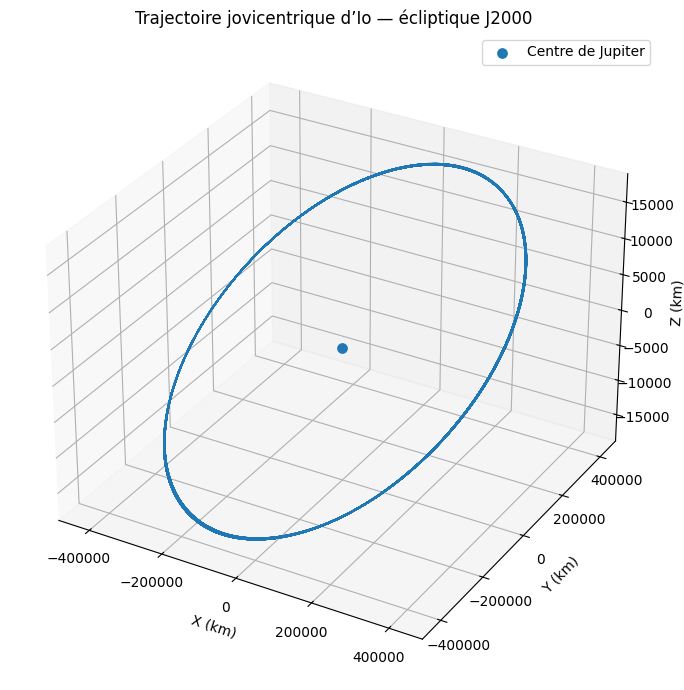

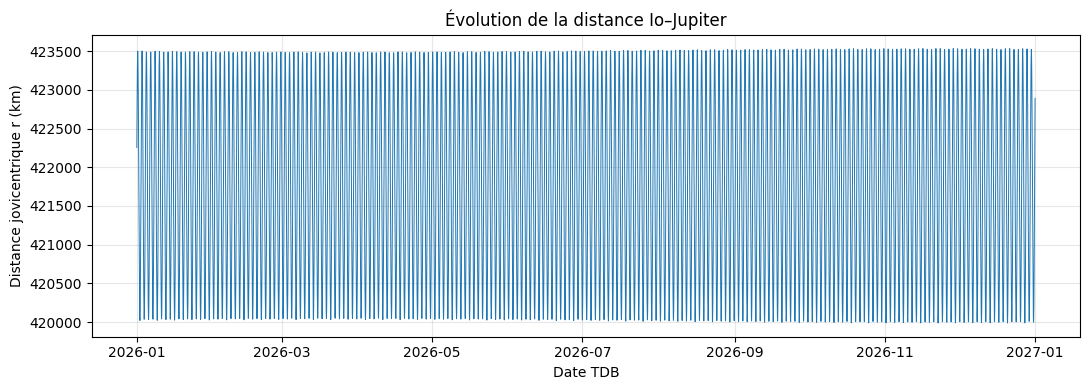


RÉSUMÉ DU VECTEUR D'ÉTAT
Nombre d'états                    : 8761
Distance moyenne à Jupiter        : 421769.612104 km
Distance minimale                 : 419988.042675 km
Distance maximale                 : 423534.397220 km
Vitesse orbitale moyenne          : 17.336983458 km/s
Écart maximal |norme(R) - RG|     : 2.328306436539e-10 km

Validation géométrique réussie.
La norme de position reconstruite concorde avec RG.


In [ ]:
# ============================================================
# Étape 4 — Construction du vecteur d’état d’Io
# ============================================================

# ------------------------------------------------------------
# 1. Construction des vecteurs cartésiens
# ------------------------------------------------------------

R_io = io_raw[["X_km", "Y_km", "Z_km"]].to_numpy(dtype=float)

V_io = io_raw[
    ["VX_km_s", "VY_km_s", "VZ_km_s"]
].to_numpy(dtype=float)

t_io = io_raw["Date_TDB"].to_numpy()
jd_io = io_raw["JDTDB"].to_numpy(dtype=float)

print("=" * 90)
print("CONSTRUCTION DU VECTEUR D'ÉTAT")
print("=" * 90)

print(f"Forme de R_io : {R_io.shape}")
print(f"Forme de V_io : {V_io.shape}")
print(f"Nombre de dates : {len(t_io)}")


# ------------------------------------------------------------
# 2. Normes de position et de vitesse
# ------------------------------------------------------------

r_io_km = np.linalg.norm(R_io, axis=1)
v_io_km_s = np.linalg.norm(V_io, axis=1)

# Distance fournie directement par Horizons
rg_horizons_km = io_raw["RG_km"].to_numpy(dtype=float)

# Écart entre la norme reconstruite et RG
ecart_r_rg_km = r_io_km - rg_horizons_km

ecart_r_rg_abs_km = np.abs(ecart_r_rg_km)

# Erreur relative, protégée contre une éventuelle division nulle
erreur_relative_r_rg = np.divide(
    ecart_r_rg_abs_km,
    rg_horizons_km,
    out=np.full_like(ecart_r_rg_abs_km, np.nan),
    where=rg_horizons_km != 0
)


# ------------------------------------------------------------
# 3. Ajout des variables au DataFrame
# ------------------------------------------------------------

io_state = io_raw.copy()

io_state["r_km"] = r_io_km
io_state["v_km_s"] = v_io_km_s
io_state["ecart_r_RG_km"] = ecart_r_rg_km
io_state["erreur_relative_r_RG"] = erreur_relative_r_rg


# ------------------------------------------------------------
# 4. Statistiques descriptives
# ------------------------------------------------------------

resume_etat = pd.DataFrame({
    "Observable": [
        "r_min_km",
        "r_mean_km",
        "r_median_km",
        "r_max_km",
        "r_std_km",
        "v_min_km_s",
        "v_mean_km_s",
        "v_median_km_s",
        "v_max_km_s",
        "v_std_km_s",
        "ecart_r_RG_moyen_km",
        "ecart_r_RG_max_abs_km",
        "erreur_relative_r_RG_max",
    ],
    "Valeur": [
        np.min(r_io_km),
        np.mean(r_io_km),
        np.median(r_io_km),
        np.max(r_io_km),
        np.std(r_io_km),
        np.min(v_io_km_s),
        np.mean(v_io_km_s),
        np.median(v_io_km_s),
        np.max(v_io_km_s),
        np.std(v_io_km_s),
        np.mean(ecart_r_rg_km),
        np.max(ecart_r_rg_abs_km),
        np.nanmax(erreur_relative_r_rg),
    ]
})

display(resume_etat)


# ------------------------------------------------------------
# 5. Validation de cohérence géométrique
# ------------------------------------------------------------

tolerance_rg_km = 1e-6

n_ecarts_rg = int(
    np.sum(ecart_r_rg_abs_km > tolerance_rg_km)
)

validation_rg = n_ecarts_rg == 0

controle_etat = pd.DataFrame({
    "Controle": [
        "Nombre d'états",
        "Dimension de l'espace de position",
        "Dimension de l'espace de vitesse",
        "Valeurs non finies dans R_io",
        "Valeurs non finies dans V_io",
        "Écarts |r - RG| > tolérance",
        "Tolérance sur |r - RG| (km)",
        "Validation norme position / RG",
    ],
    "Valeur": [
        len(R_io),
        R_io.shape[1],
        V_io.shape[1],
        int((~np.isfinite(R_io)).sum()),
        int((~np.isfinite(V_io)).sum()),
        n_ecarts_rg,
        tolerance_rg_km,
        validation_rg,
    ]
})

print("\n" + "=" * 90)
print("VALIDATION DU VECTEUR D'ÉTAT")
print("=" * 90)

display(controle_etat)


# ------------------------------------------------------------
# 6. Aperçu du tableau enrichi
# ------------------------------------------------------------

colonnes_apercu = [
    "Date_TDB",
    "X_km",
    "Y_km",
    "Z_km",
    "VX_km_s",
    "VY_km_s",
    "VZ_km_s",
    "r_km",
    "RG_km",
    "v_km_s",
    "ecart_r_RG_km",
]

display(io_state[colonnes_apercu].head())


# ------------------------------------------------------------
# 7. Visualisation de la trajectoire
# ------------------------------------------------------------

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    R_io[:, 0],
    R_io[:, 1],
    R_io[:, 2],
    linewidth=0.5
)

ax.scatter(
    [0.0],
    [0.0],
    [0.0],
    s=45,
    label="Centre de Jupiter"
)

ax.set_title(
    "Trajectoire jovicentrique d’Io — écliptique J2000"
)
ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")
ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Évolution de la distance jovicentrique
# ------------------------------------------------------------

plt.figure(figsize=(11, 4))

plt.plot(
    io_state["Date_TDB"],
    io_state["r_km"],
    linewidth=0.7
)

plt.xlabel("Date TDB")
plt.ylabel("Distance jovicentrique r (km)")
plt.title("Évolution de la distance Io–Jupiter")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Résumé final
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("RÉSUMÉ DU VECTEUR D'ÉTAT")
print("=" * 90)

print(f"Nombre d'états                    : {len(R_io)}")
print(f"Distance moyenne à Jupiter        : {np.mean(r_io_km):.6f} km")
print(f"Distance minimale                 : {np.min(r_io_km):.6f} km")
print(f"Distance maximale                 : {np.max(r_io_km):.6f} km")
print(f"Vitesse orbitale moyenne          : {np.mean(v_io_km_s):.9f} km/s")
print(f"Écart maximal |norme(R) - RG|     : {np.max(ecart_r_rg_abs_km):.12e} km")

if validation_rg:
    print("\nValidation géométrique réussie.")
    print("La norme de position reconstruite concorde avec RG.")
else:
    print("\nAttention : un écart avec RG dépasse la tolérance choisie.")

### Validation de la construction du vecteur d’état

Le vecteur d’état jovicentrique d’Io a été construit à partir de 8761 observations horaires couvrant l’année 2026.

La distance moyenne à Jupiter vaut environ :

\[
\langle r\rangle = 421\,769.61\ \mathrm{km},
\]

avec une variation comprise entre :

\[
r_{\min}=419\,988.04\ \mathrm{km}
\]

et

\[
r_{\max}=423\,534.40\ \mathrm{km}.
\]

La vitesse orbitale moyenne obtenue est :

\[
\langle v\rangle = 17.33698\ \mathrm{km\,s^{-1}}.
\]

La norme du vecteur de position reconstruit concorde avec la distance `RG` fournie par NASA/JPL Horizons avec un écart maximal de seulement :

\[
2.33\times10^{-10}\ \mathrm{km}.
\]

Cette concordance valide la lecture des coordonnées cartésiennes et la construction du vecteur d’état d’Io. Les données peuvent maintenant être utilisées pour calculer les transitions géométriques GVH entre états successifs.

## 5. Calcul des transitions géométriques \(D_T\)

À partir des positions jovicentriques successives d’Io, on définit les incréments géométriques :

\[
\Delta\mathbf{R}_i
=
\mathbf{R}_{i+1}-\mathbf{R}_i.
\]

L’observable locale GVH est la norme euclidienne de cet incrément :

\[
D_T(i)
=
\left\|\Delta\mathbf{R}_i\right\|
=
\sqrt{
(\Delta X_i)^2+
(\Delta Y_i)^2+
(\Delta Z_i)^2
}.
\]

Avec 8761 états horaires, la série contient :

\[
8761-1=8760
\]

transitions géométriques.

Dans ce pipeline, \(D_T\) est une distance cordale entre deux positions successives. Elle ne doit pas être confondue avec la variation de la distance radiale Io–Jupiter :

\[
|r_{i+1}-r_i|,
\]

qui ne mesure que le déplacement radial et ignore la composante tangentielle dominante du mouvement orbital.

Une estimation cinématique indépendante est également construite à partir de la vitesse moyenne sur chaque intervalle :

\[
D_{V}(i)
=
\frac{\|\mathbf V_i\|+\|\mathbf V_{i+1}\|}{2}\Delta t.
\]

La comparaison entre \(D_T\) et \(D_V\) permet de contrôler la cohérence locale entre les positions et les vitesses fournies par Horizons.

CONSTRUCTION DES TRANSITIONS GÉOMÉTRIQUES
Nombre d'états                 : 8761
Nombre d'incréments            : 8760
Nombre de valeurs D_T          : 8760
Forme de delta_R_io            : (8760, 3)


,Observable,Valeur
0,D_T_min_km,62095.619747
1,D_T_q01_km,62098.019537
2,D_T_q05_km,62103.477223
3,D_T_q25_km,62174.218619
4,D_T_median_km,62354.853614
5,D_T_mean_km,62356.220153
6,D_T_q75_km,62537.952201
7,D_T_q95_km,62611.516788
8,D_T_q99_km,62616.930042
9,D_T_max_km,62619.610046



VALIDATION DES TRANSITIONS GÉOMÉTRIQUES


,Controle,Valeur
0,Nombre d'états,8761
1,Nombre attendu de transitions,8760
2,Nombre obtenu de transitions,8760
3,Dimension des incréments,3
4,Valeurs non finies dans delta_R_io,0
5,Valeurs non finies dans D_T,0
6,Valeurs D_T négatives,0
7,Valeurs D_T nulles,0
8,Erreur max entre les deux formules de D_T (km),0.0
9,Longueur cohérente avec N - 1,True



Premières transitions :


,Date_debut_TDB,Date_fin_TDB,Date_milieu_TDB,dt_s,dX_km,dY_km,dZ_km,D_T_km,D_vdt_km,ecart_D_T_vdt_km,erreur_relative_D_T_vdt,delta_r_km,abs_delta_r_km,rapport_radial_sur_D_T
0,2026-01-01 00:00:00,2026-01-01 01:00:00,2026-01-01 00:30:00,3600.0,25774.329760,56630.865268,2394.180806,62266.388022,62323.237958,-56.849937,0.000912,240.071358,240.071358,0.003856
1,2026-01-01 01:00:00,2026-01-01 02:00:00,2026-01-01 01:30:00,3600.0,17142.335769,59776.978779,2384.957113,62232.104962,62288.922575,-56.817613,0.000912,224.101693,224.101693,0.003601
2,2026-01-01 02:00:00,2026-01-01 03:00:00,2026-01-01 02:30:00,3600.0,8151.777208,61620.234686,2323.965424,62200.527407,62257.316201,-56.788794,0.000912,203.284158,203.284158,0.003268
3,2026-01-01 03:00:00,2026-01-01 04:00:00,2026-01-01 03:30:00,3600.0,-1002.656676,62124.857206,2212.674778,62172.334144,62229.098488,-56.764343,0.000912,178.058827,178.058827,0.002864
4,2026-01-01 04:00:00,2026-01-01 05:00:00,2026-01-01 04:30:00,3600.0,-10123.916359,61283.606054,2053.610445,62148.140513,62204.884593,-56.744080,0.000912,148.964109,148.964109,0.002397


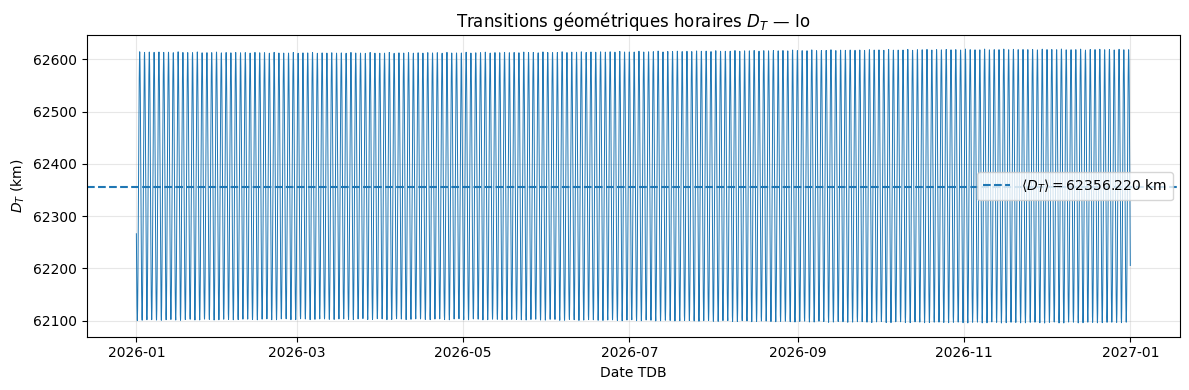

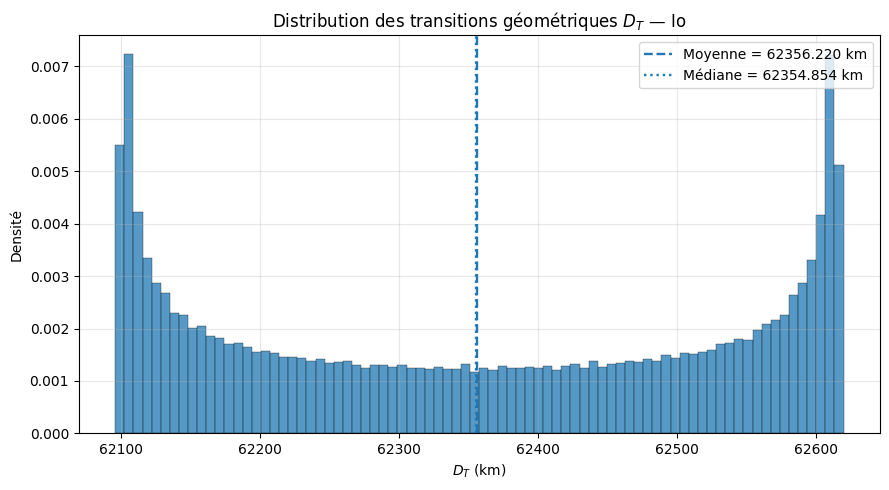

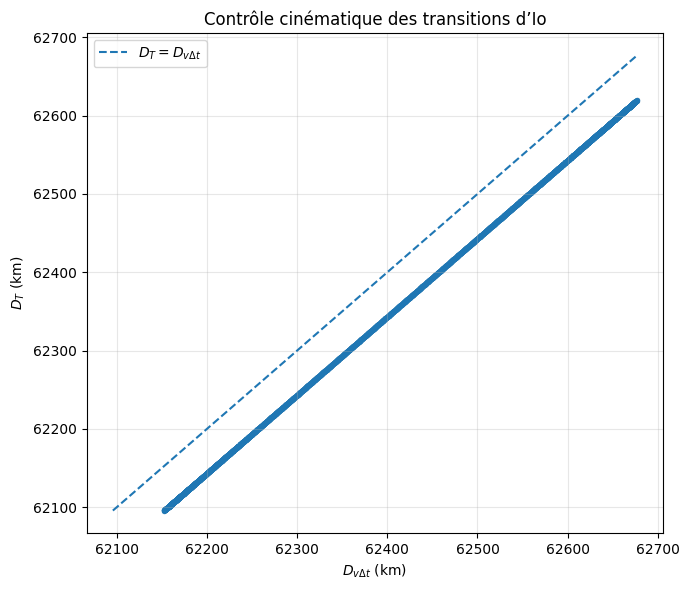


RÉSUMÉ DES TRANSITIONS GÉOMÉTRIQUES
Nombre de transitions              : 8760
D_T moyen                          : 62356.220152603 km
D_T médian                         : 62354.853614234 km
D_T minimum                        : 62095.619746527 km
D_T maximum                        : 62619.610045634 km
Écart-type de D_T                  : 182.102161874 km
Erreur max formule norme/directe   : 0.000000000000e+00 km
Erreur relative moyenne D_T / vdt  : 9.122103327981e-04
Part radiale moyenne du déplacement : 0.264012 %

Validation des transitions géométriques réussie.


In [ ]:
# ============================================================
# Étape 5 — Calcul des transitions géométriques D_T
# ============================================================

# ------------------------------------------------------------
# 1. Incréments entre positions successives
# ------------------------------------------------------------

delta_R_io = np.diff(R_io, axis=0)

delta_X_km = delta_R_io[:, 0]
delta_Y_km = delta_R_io[:, 1]
delta_Z_km = delta_R_io[:, 2]

# Distance cordale entre deux positions horaires successives
D_T = np.linalg.norm(delta_R_io, axis=1)

# Dates associées aux transitions
# Convention : chaque transition est datée à son extrémité finale
t_D = io_state["Date_TDB"].iloc[1:].reset_index(drop=True)

# Milieu temporel de chaque intervalle, utile pour les graphiques
t_D_mid = (
    io_state["Date_TDB"].iloc[:-1].reset_index(drop=True)
    + pd.to_timedelta(pas_nominal_s / 2.0, unit="s")
)

print("=" * 90)
print("CONSTRUCTION DES TRANSITIONS GÉOMÉTRIQUES")
print("=" * 90)

print(f"Nombre d'états                 : {len(R_io)}")
print(f"Nombre d'incréments            : {len(delta_R_io)}")
print(f"Nombre de valeurs D_T          : {len(D_T)}")
print(f"Forme de delta_R_io            : {delta_R_io.shape}")


# ------------------------------------------------------------
# 2. Contrôle par calcul direct
# ------------------------------------------------------------

D_T_direct = np.sqrt(
    delta_X_km**2
    + delta_Y_km**2
    + delta_Z_km**2
)

erreur_formule_D_T = np.abs(D_T - D_T_direct)
erreur_formule_D_T_max = np.max(erreur_formule_D_T)


# ------------------------------------------------------------
# 3. Comparaison avec la distance cinématique v * dt
# ------------------------------------------------------------

dt_s = delta_t_datetime_s

# Norme moyenne de la vitesse aux deux extrémités
v_intervalle_km_s = 0.5 * (
    v_io_km_s[:-1] + v_io_km_s[1:]
)

# Distance estimée par vitesse moyenne × durée
D_vdt_km = v_intervalle_km_s * dt_s

ecart_D_T_vdt_km = D_T - D_vdt_km

erreur_relative_D_T_vdt = np.divide(
    np.abs(ecart_D_T_vdt_km),
    D_vdt_km,
    out=np.full_like(D_T, np.nan),
    where=D_vdt_km != 0
)


# ------------------------------------------------------------
# 4. Variation radiale, distincte de D_T
# ------------------------------------------------------------

delta_r_km = np.diff(r_io_km)
abs_delta_r_km = np.abs(delta_r_km)

rapport_radial_total = np.divide(
    abs_delta_r_km,
    D_T,
    out=np.full_like(D_T, np.nan),
    where=D_T != 0
)


# ------------------------------------------------------------
# 5. Tableau complet des transitions
# ------------------------------------------------------------

io_transitions = pd.DataFrame({
    "Date_debut_TDB": (
        io_state["Date_TDB"]
        .iloc[:-1]
        .reset_index(drop=True)
    ),
    "Date_fin_TDB": t_D,
    "Date_milieu_TDB": t_D_mid,
    "dt_s": dt_s,
    "dX_km": delta_X_km,
    "dY_km": delta_Y_km,
    "dZ_km": delta_Z_km,
    "D_T_km": D_T,
    "D_vdt_km": D_vdt_km,
    "ecart_D_T_vdt_km": ecart_D_T_vdt_km,
    "erreur_relative_D_T_vdt": erreur_relative_D_T_vdt,
    "delta_r_km": delta_r_km,
    "abs_delta_r_km": abs_delta_r_km,
    "rapport_radial_sur_D_T": rapport_radial_total,
})


# ------------------------------------------------------------
# 6. Statistiques descriptives de D_T
# ------------------------------------------------------------

D_T_mean = np.mean(D_T)
D_T_median = np.median(D_T)
D_T_std = np.std(D_T)
D_T_min = np.min(D_T)
D_T_max = np.max(D_T)

quantiles_D_T = np.percentile(
    D_T,
    [1, 5, 25, 50, 75, 95, 99]
)

resume_D_T = pd.DataFrame({
    "Observable": [
        "D_T_min_km",
        "D_T_q01_km",
        "D_T_q05_km",
        "D_T_q25_km",
        "D_T_median_km",
        "D_T_mean_km",
        "D_T_q75_km",
        "D_T_q95_km",
        "D_T_q99_km",
        "D_T_max_km",
        "D_T_std_km",
        "D_vdt_mean_km",
        "ecart_D_T_vdt_mean_km",
        "ecart_D_T_vdt_max_abs_km",
        "erreur_relative_D_T_vdt_mean",
        "erreur_relative_D_T_vdt_max",
        "abs_delta_r_mean_km",
        "rapport_radial_sur_D_T_mean",
    ],
    "Valeur": [
        D_T_min,
        quantiles_D_T[0],
        quantiles_D_T[1],
        quantiles_D_T[2],
        D_T_median,
        D_T_mean,
        quantiles_D_T[4],
        quantiles_D_T[5],
        quantiles_D_T[6],
        D_T_max,
        D_T_std,
        np.mean(D_vdt_km),
        np.mean(ecart_D_T_vdt_km),
        np.max(np.abs(ecart_D_T_vdt_km)),
        np.nanmean(erreur_relative_D_T_vdt),
        np.nanmax(erreur_relative_D_T_vdt),
        np.mean(abs_delta_r_km),
        np.nanmean(rapport_radial_total),
    ]
})

display(resume_D_T)


# ------------------------------------------------------------
# 7. Validation structurelle
# ------------------------------------------------------------

controle_D_T = pd.DataFrame({
    "Controle": [
        "Nombre d'états",
        "Nombre attendu de transitions",
        "Nombre obtenu de transitions",
        "Dimension des incréments",
        "Valeurs non finies dans delta_R_io",
        "Valeurs non finies dans D_T",
        "Valeurs D_T négatives",
        "Valeurs D_T nulles",
        "Erreur max entre les deux formules de D_T (km)",
        "Longueur cohérente avec N - 1",
    ],
    "Valeur": [
        len(R_io),
        len(R_io) - 1,
        len(D_T),
        delta_R_io.shape[1],
        int((~np.isfinite(delta_R_io)).sum()),
        int((~np.isfinite(D_T)).sum()),
        int(np.sum(D_T < 0)),
        int(np.sum(D_T == 0)),
        erreur_formule_D_T_max,
        len(D_T) == len(R_io) - 1,
    ]
})

print("\n" + "=" * 90)
print("VALIDATION DES TRANSITIONS GÉOMÉTRIQUES")
print("=" * 90)

display(controle_D_T)

print("\nPremières transitions :")
display(io_transitions.head())


# ------------------------------------------------------------
# 8. Série temporelle de D_T
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(
    io_transitions["Date_milieu_TDB"],
    io_transitions["D_T_km"],
    linewidth=0.7
)

plt.axhline(
    D_T_mean,
    linestyle="--",
    linewidth=1.5,
    label=fr"$\langle D_T\rangle={D_T_mean:.3f}\ \mathrm{{km}}$"
)

plt.xlabel("Date TDB")
plt.ylabel(r"$D_T$ (km)")
plt.title(
    r"Transitions géométriques horaires $D_T$ — Io"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Distribution de D_T
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    D_T,
    bins=80,
    density=True,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.75
)

plt.axvline(
    D_T_mean,
    linestyle="--",
    linewidth=1.7,
    label=fr"Moyenne = {D_T_mean:.3f} km"
)

plt.axvline(
    D_T_median,
    linestyle=":",
    linewidth=1.7,
    label=fr"Médiane = {D_T_median:.3f} km"
)

plt.xlabel(r"$D_T$ (km)")
plt.ylabel("Densité")
plt.title(r"Distribution des transitions géométriques $D_T$ — Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Comparaison D_T et v × dt
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    D_vdt_km,
    D_T,
    s=8,
    alpha=0.45
)

borne_min = min(np.min(D_vdt_km), np.min(D_T))
borne_max = max(np.max(D_vdt_km), np.max(D_T))

plt.plot(
    [borne_min, borne_max],
    [borne_min, borne_max],
    linestyle="--",
    linewidth=1.5,
    label=r"$D_T=D_{v\Delta t}$"
)

plt.xlabel(r"$D_{v\Delta t}$ (km)")
plt.ylabel(r"$D_T$ (km)")
plt.title("Contrôle cinématique des transitions d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Résumé final
# ------------------------------------------------------------

validation_D_T = (
    len(D_T) == len(R_io) - 1
    and np.isfinite(D_T).all()
    and np.all(D_T > 0)
    and erreur_formule_D_T_max < 1e-9
)

print("\n" + "=" * 90)
print("RÉSUMÉ DES TRANSITIONS GÉOMÉTRIQUES")
print("=" * 90)

print(f"Nombre de transitions              : {len(D_T)}")
print(f"D_T moyen                          : {D_T_mean:.9f} km")
print(f"D_T médian                         : {D_T_median:.9f} km")
print(f"D_T minimum                        : {D_T_min:.9f} km")
print(f"D_T maximum                        : {D_T_max:.9f} km")
print(f"Écart-type de D_T                  : {D_T_std:.9f} km")
print(
    "Erreur max formule norme/directe   : "
    f"{erreur_formule_D_T_max:.12e} km"
)
print(
    "Erreur relative moyenne D_T / vdt  : "
    f"{np.nanmean(erreur_relative_D_T_vdt):.12e}"
)
print(
    "Part radiale moyenne du déplacement : "
    f"{100*np.nanmean(rapport_radial_total):.6f} %"
)

if validation_D_T:
    print("\nValidation des transitions géométriques réussie.")
else:
    print("\nAttention : une anomalie a été détectée dans D_T.")

### Validation des transitions géométriques

Les 8761 positions jovicentriques d’Io produisent 8760 transitions géométriques horaires :

\[
D_T(i)=\left\|\mathbf R_{i+1}-\mathbf R_i\right\|.
\]

La distance cordale moyenne entre deux positions successives vaut :

\[
\langle D_T\rangle
=
62\,356.220\ \mathrm{km},
\]

avec :

\[
D_{T,\min}
=
62\,095.620\ \mathrm{km},
\]

\[
D_{T,\max}
=
62\,619.610\ \mathrm{km},
\]

et :

\[
\sigma(D_T)
=
182.102\ \mathrm{km}.
\]

La dispersion relative de \(D_T\) est d’environ \(0.292\%\), ce qui montre une dynamique orbitale horaire très régulière.

La distance cinématique estimée à partir de \(v\Delta t\) vaut en moyenne :

\[
62\,413.154\ \mathrm{km}.
\]

Elle dépasse \(D_T\) d’environ \(56.934\ \mathrm{km}\), soit seulement \(0.0912\%\). Cette différence est cohérente avec la distinction entre la longueur de l’arc orbital et la corde reliant deux positions successives.

Enfin, la variation radiale moyenne ne représente qu’environ \(0.264\%\) du déplacement géométrique total. Le mouvement local d’Io est donc principalement tangentiel.

La construction de \(D_T\) est validée et peut maintenant servir au calcul des observables GVH.

## 6. Dispersion et régions supercritiques

La série des transitions géométriques horaires d’Io est notée :

\[
\{D_T(i)\}_{i=1}^{N},
\qquad N=8760.
\]

La dispersion globale des transitions est définie par :

\[
S_T
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(D_T(i)-\langle D_T\rangle\right)^2
}.
\]

Une version sans dimension est construite par normalisation à la transition moyenne :

\[
S_{T,\mathrm{norm}}
=
\frac{S_T}{\langle D_T\rangle}.
\]

Le seuil critique est fixé au quantile \(95\%\) de la distribution :

\[
D_c=Q_{0.95}(D_T).
\]

Une transition est dite supercritique lorsque :

\[
D_T(i)>D_c.
\]

La fraction supercritique est alors :

\[
R_{\mathrm{super}}
=
\frac{N(D_T>D_c)}{N_{\mathrm{total}}}.
\]

Le choix du quantile \(95\%\) permet une comparaison méthodologique directe avec les autres pipelines trajectoriels fondés sur la même convention.

OBSERVABLES GVH DE DISPERSION ET DE SUPERCRITICITÉ


,Observable,Valeur
0,N_transitions,8.760000e+03
1,D_T_mean_km,6.235622e+04
2,D_T_median_km,6.235485e+04
3,S_T_km,1.821022e+02
4,S_T_norm,2.920353e-03
5,Quantile_D_c,9.500000e-01
6,D_c_km,6.261152e+04
7,N_super,4.380000e+02
8,R_super,5.000000e-02
9,R_super_attendu_quantile,5.000000e-02



VALIDATION DES OBSERVABLES


,Controle,Valeur
0,S_T fini et positif,True
1,S_T_norm fini et positif,True
2,D_c compris entre min(D_T) et max(D_T),True
3,R_super compris entre 0 et 1,True
4,R_super compatible avec le quantile 95 %,True
5,Nombre total de transitions,8760
6,Nombre de transitions supercritiques,438
7,Nombre supercritique théorique approximatif,438.0
8,Tolérance discrète sur R_super,0.000114


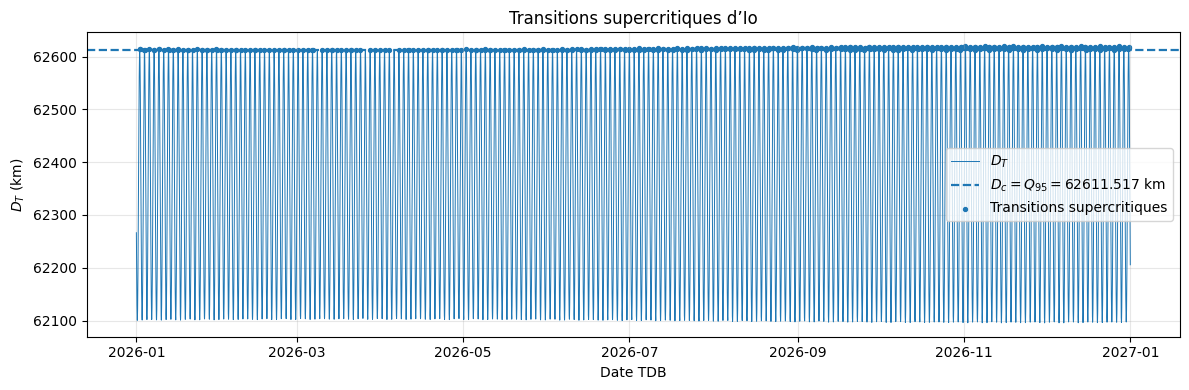

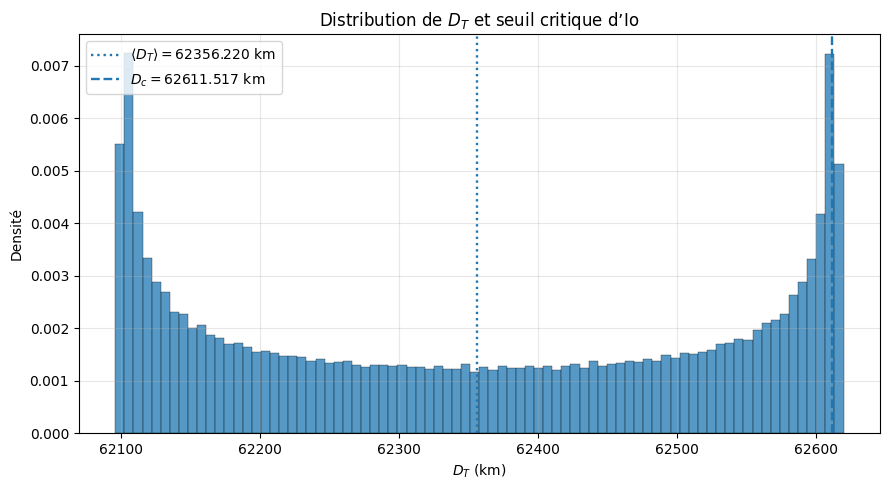


Premières transitions supercritiques :


,Date_debut_TDB,Date_fin_TDB,Date_milieu_TDB,D_T_km,D_c_km,D_T_moins_D_c_km,exces_relatif_D_c
0,2026-01-02 05:00:00,2026-01-02 06:00:00,2026-01-02 05:30:00,62614.345697,62611.516788,2.828908,0.000045
1,2026-01-02 06:00:00,2026-01-02 07:00:00,2026-01-02 06:30:00,62613.612184,62611.516788,2.095395,0.000033
2,2026-01-03 23:00:00,2026-01-04 00:00:00,2026-01-03 23:30:00,62612.086795,62611.516788,0.570006,0.000009
3,2026-01-04 00:00:00,2026-01-04 01:00:00,2026-01-04 00:30:00,62613.206892,62611.516788,1.690103,0.000027
4,2026-01-05 18:00:00,2026-01-05 19:00:00,2026-01-05 18:30:00,62613.849529,62611.516788,2.332741,0.000037



RÉSUMÉ GVH — DISPERSION ET SUPERCRITICITÉ
D_T moyen                     : 62356.220152603 km
D_T médian                    : 62354.853614234 km
S_T                           : 182.102161874 km
S_T_norm                      : 0.002920352796
S_T_norm en pourcentage       : 0.292035 %
D_c — quantile 95 %           : 62611.516788499 km
Nombre supercritique          : 438
R_super                       : 0.050000000000
R_super en pourcentage        : 5.000000 %
D_T moyen supercritique       : 62614.663128613 km
D_T minimum supercritique     : 62611.517582094 km
D_T maximum supercritique     : 62619.610045634 km

Validation des observables GVH réussie.


In [ ]:
# ============================================================
# Étape 6 — S_T, S_T_norm, D_c et R_super
# ============================================================

# ------------------------------------------------------------
# 1. Vérification de la série D_T
# ------------------------------------------------------------

D_T = np.asarray(D_T, dtype=float)

if D_T.ndim != 1:
    raise ValueError("D_T doit être une série unidimensionnelle.")

if len(D_T) != 8760:
    raise ValueError(
        f"Nombre inattendu de transitions : {len(D_T)} au lieu de 8760."
    )

if not np.isfinite(D_T).all():
    raise ValueError("D_T contient des valeurs non finies.")

if np.any(D_T <= 0):
    raise ValueError("D_T contient au moins une valeur nulle ou négative.")


# ------------------------------------------------------------
# 2. Statistiques globales
# ------------------------------------------------------------

D_T_mean = float(np.mean(D_T))
D_T_median = float(np.median(D_T))

# Écart-type population
S_T = float(np.std(D_T, ddof=0))

if D_T_mean == 0:
    raise ZeroDivisionError(
        "La moyenne de D_T est nulle : S_T_norm est indéfini."
    )

S_T_norm = float(S_T / D_T_mean)


# ------------------------------------------------------------
# 3. Seuil critique au quantile 95 %
# ------------------------------------------------------------

quantile_critique = 0.95

D_c = float(
    np.quantile(
        D_T,
        quantile_critique,
        method="linear"
    )
)

super_mask = D_T > D_c

N_total = int(len(D_T))
N_super = int(np.sum(super_mask))

R_super = float(np.mean(super_mask))


# ------------------------------------------------------------
# 4. Quantités complémentaires
# ------------------------------------------------------------

D_T_super = D_T[super_mask]

if N_super > 0:
    D_T_super_mean = float(np.mean(D_T_super))
    D_T_super_min = float(np.min(D_T_super))
    D_T_super_max = float(np.max(D_T_super))
else:
    D_T_super_mean = np.nan
    D_T_super_min = np.nan
    D_T_super_max = np.nan

R_super_attendu = 1.0 - quantile_critique
ecart_R_super_005 = R_super - R_super_attendu
N_super_attendu = N_total * R_super_attendu


# ------------------------------------------------------------
# 5. Ajout au tableau des transitions
# ------------------------------------------------------------

io_transitions = io_transitions.copy()

io_transitions["supercritical"] = super_mask
io_transitions["D_c_km"] = D_c
io_transitions["D_T_moins_D_c_km"] = (
    io_transitions["D_T_km"] - D_c
)

io_transitions["exces_relatif_D_c"] = np.where(
    super_mask,
    (D_T - D_c) / D_c,
    0.0
)


# ------------------------------------------------------------
# 6. Tableau principal des observables
# ------------------------------------------------------------

observables_supercriticite = pd.DataFrame({
    "Observable": [
        "N_transitions",
        "D_T_mean_km",
        "D_T_median_km",
        "S_T_km",
        "S_T_norm",
        "Quantile_D_c",
        "D_c_km",
        "N_super",
        "R_super",
        "R_super_attendu_quantile",
        "Ecart_R_super_a_0.05",
        "D_T_super_mean_km",
        "D_T_super_min_km",
        "D_T_super_max_km",
    ],
    "Valeur": [
        N_total,
        D_T_mean,
        D_T_median,
        S_T,
        S_T_norm,
        quantile_critique,
        D_c,
        N_super,
        R_super,
        R_super_attendu,
        ecart_R_super_005,
        D_T_super_mean,
        D_T_super_min,
        D_T_super_max,
    ]
})

print("=" * 90)
print("OBSERVABLES GVH DE DISPERSION ET DE SUPERCRITICITÉ")
print("=" * 90)

display(observables_supercriticite)


# ------------------------------------------------------------
# 7. Contrôles de validation
# ------------------------------------------------------------

tolerance_fraction = 1.0 / N_total

validation_S_T = (
    np.isfinite(S_T)
    and S_T > 0
)

validation_S_T_norm = (
    np.isfinite(S_T_norm)
    and S_T_norm > 0
)

validation_D_c = (
    np.min(D_T) <= D_c <= np.max(D_T)
)

validation_R_super = (
    0.0 <= R_super <= 1.0
)

validation_quantile = (
    abs(R_super - R_super_attendu)
    <= tolerance_fraction + 1e-12
)

controle_supercriticite = pd.DataFrame({
    "Controle": [
        "S_T fini et positif",
        "S_T_norm fini et positif",
        "D_c compris entre min(D_T) et max(D_T)",
        "R_super compris entre 0 et 1",
        "R_super compatible avec le quantile 95 %",
        "Nombre total de transitions",
        "Nombre de transitions supercritiques",
        "Nombre supercritique théorique approximatif",
        "Tolérance discrète sur R_super",
    ],
    "Valeur": [
        validation_S_T,
        validation_S_T_norm,
        validation_D_c,
        validation_R_super,
        validation_quantile,
        N_total,
        N_super,
        N_super_attendu,
        tolerance_fraction,
    ]
})

print("\n" + "=" * 90)
print("VALIDATION DES OBSERVABLES")
print("=" * 90)

display(controle_supercriticite)


# ------------------------------------------------------------
# 8. Visualisation temporelle avec seuil critique
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(
    io_transitions["Date_milieu_TDB"],
    io_transitions["D_T_km"],
    linewidth=0.7,
    label=r"$D_T$"
)

plt.axhline(
    D_c,
    linestyle="--",
    linewidth=1.6,
    label=fr"$D_c=Q_{{95}}={D_c:.3f}\ \mathrm{{km}}$"
)

plt.scatter(
    io_transitions.loc[
        io_transitions["supercritical"],
        "Date_milieu_TDB"
    ],
    io_transitions.loc[
        io_transitions["supercritical"],
        "D_T_km"
    ],
    s=8,
    label="Transitions supercritiques"
)

plt.xlabel("Date TDB")
plt.ylabel(r"$D_T$ (km)")
plt.title("Transitions supercritiques d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Histogramme avec seuil D_c
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    D_T,
    bins=80,
    density=True,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.75
)

plt.axvline(
    D_T_mean,
    linestyle=":",
    linewidth=1.7,
    label=fr"$\langle D_T\rangle={D_T_mean:.3f}\ \mathrm{{km}}$"
)

plt.axvline(
    D_c,
    linestyle="--",
    linewidth=1.7,
    label=fr"$D_c={D_c:.3f}\ \mathrm{{km}}$"
)

plt.xlabel(r"$D_T$ (km)")
plt.ylabel("Densité")
plt.title(r"Distribution de $D_T$ et seuil critique d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Tableau des transitions supercritiques
# ------------------------------------------------------------

transitions_supercritiques = (
    io_transitions.loc[
        io_transitions["supercritical"],
        [
            "Date_debut_TDB",
            "Date_fin_TDB",
            "Date_milieu_TDB",
            "D_T_km",
            "D_c_km",
            "D_T_moins_D_c_km",
            "exces_relatif_D_c",
        ]
    ]
    .reset_index(drop=True)
)

print("\nPremières transitions supercritiques :")
display(transitions_supercritiques.head())


# ------------------------------------------------------------
# 11. Résumé final
# ------------------------------------------------------------

validation_globale = all([
    validation_S_T,
    validation_S_T_norm,
    validation_D_c,
    validation_R_super,
    validation_quantile,
])

print("\n" + "=" * 90)
print("RÉSUMÉ GVH — DISPERSION ET SUPERCRITICITÉ")
print("=" * 90)

print(f"D_T moyen                     : {D_T_mean:.9f} km")
print(f"D_T médian                    : {D_T_median:.9f} km")
print(f"S_T                           : {S_T:.9f} km")
print(f"S_T_norm                      : {S_T_norm:.12f}")
print(f"S_T_norm en pourcentage       : {100*S_T_norm:.6f} %")
print(f"D_c — quantile 95 %           : {D_c:.9f} km")
print(f"Nombre supercritique          : {N_super}")
print(f"R_super                       : {R_super:.12f}")
print(f"R_super en pourcentage        : {100*R_super:.6f} %")
print(f"D_T moyen supercritique       : {D_T_super_mean:.9f} km")
print(f"D_T minimum supercritique     : {D_T_super_min:.9f} km")
print(f"D_T maximum supercritique     : {D_T_super_max:.9f} km")

if validation_globale:
    print("\nValidation des observables GVH réussie.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

## 7. Fonction de survie et comparaison des modèles

Les transitions géométriques sont normalisées par leur maximum :

\[
u_i=\frac{D_T(i)}{D_{T,\max}},
\qquad 0<u_i\leq1.
\]

La fonction de survie empirique est définie par :

\[
R(u)=P(U>u).
\]

Elle mesure la fraction des transitions normalisées qui dépassent un seuil \(u\).

Trois modèles sont ajustés :

### Modèle exponentiel

\[
R_{\exp}(u)=A_H e^{-B_Hu}.
\]

### Modèle de Weibull

\[
R_{\mathrm{Wei}}(u)=
\exp\left[
-\left(\frac{u}{\lambda}\right)^k
\right].
\]

### Modèle logistique

\[
R_{\mathrm{log}}(u)=
\frac{1}{
1+\exp\left(\frac{u-u_0}{s}\right)
}.
\]

Les modèles sont comparés à l’aide de :

\[
R^2,
\qquad
\mathrm{RMSE},
\qquad
\mathrm{AIC}.
\]

Le meilleur modèle est celui dont l’AIC est minimal, sous réserve d’un ajustement numérique valide.

CONSTRUCTION DE LA FONCTION DE SURVIE
Nombre total de transitions       : 8760
Nombre de valeurs uniques de u     : 8760
Nombre de points utilisés au fit    : 8759
u minimum                           : 0.991632169240
u maximum                           : 1.000000000000

COMPARAISON DES MODÈLES DE SURVIE


,Modele,Succes,R2,RMSE,RSS,AIC,AICc,Parametres,Message
0,Logistique,True,0.968608,0.051141,22.908124,-52080.039563,-52080.038192,u0=0.995786765795; s=0.00217279842997,Ajustement réussi
1,Weibull,True,0.967316,0.052183,23.851408,-51726.599414,-51726.598044,lambda=0.997238955703; k=317.694749787,Ajustement réussi
2,Exponentiel,True,0.029894,0.284295,707.934961,-22029.131322,-22029.129951,A_H=10; B_H=3.00513349735,Ajustement réussi


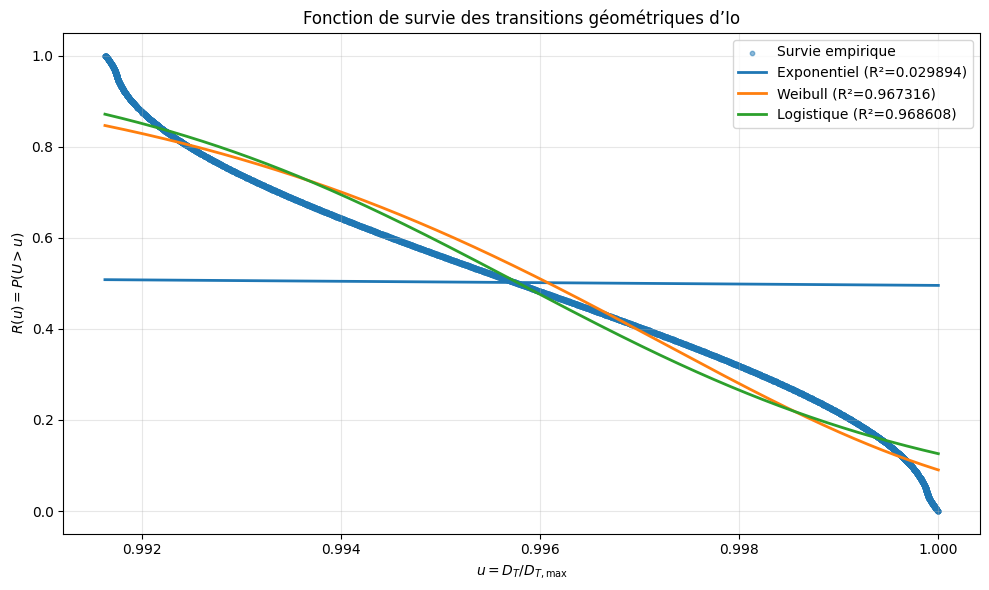

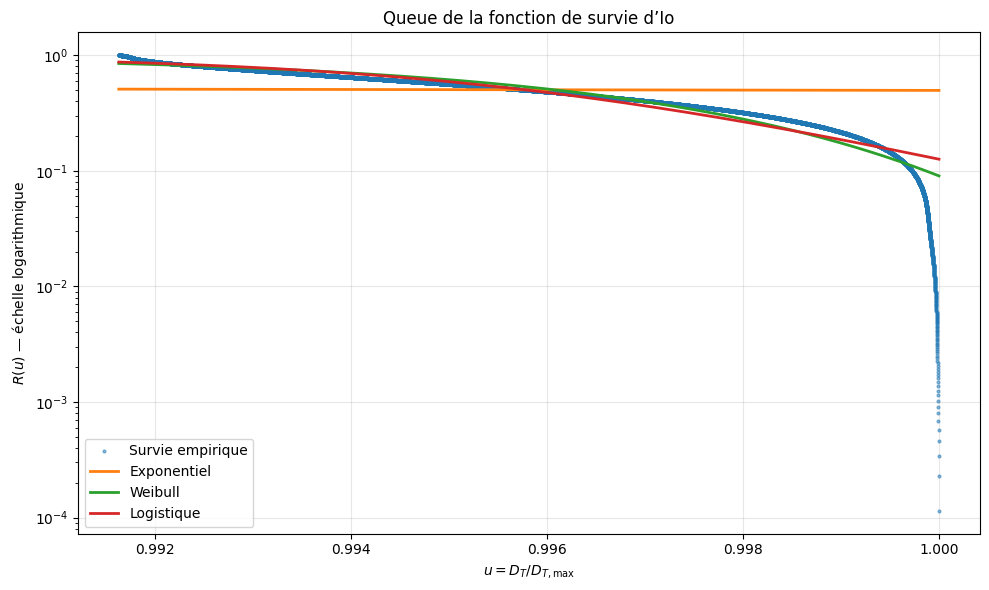

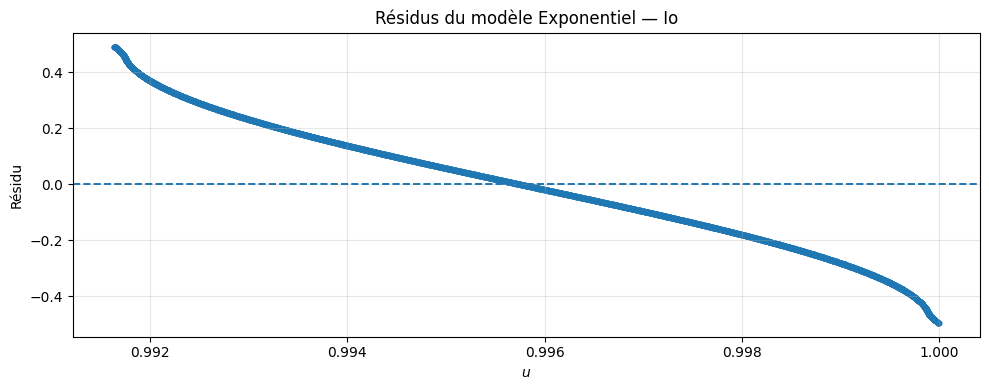

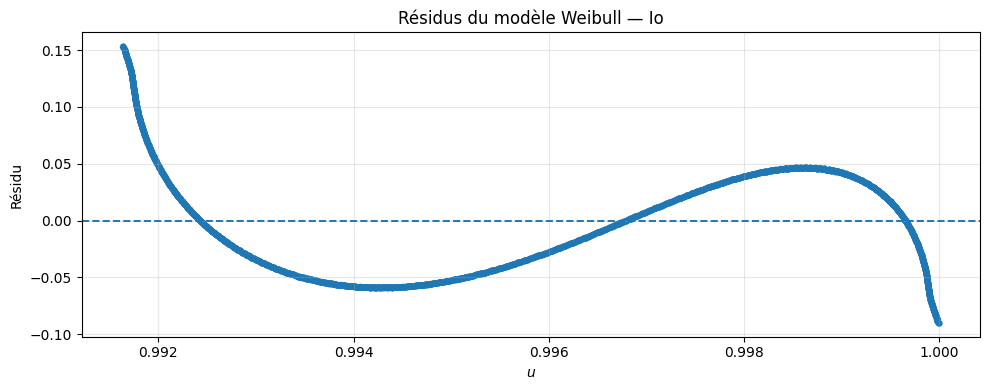

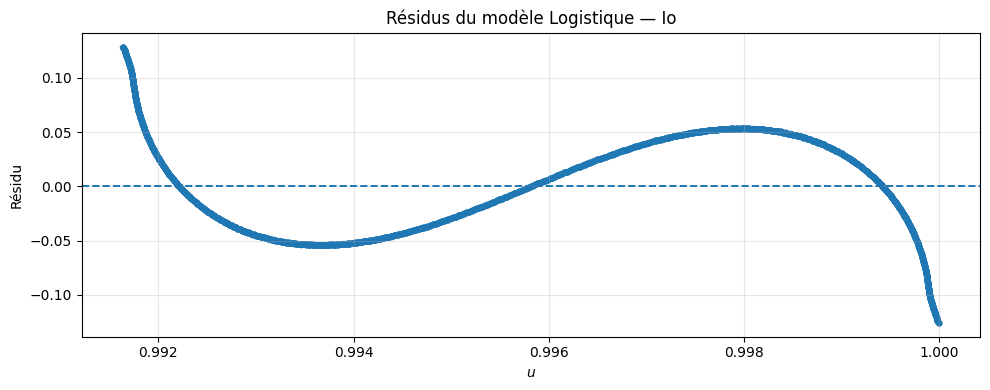


OBSERVABLES DE SURVIE — Io


,Observable,Valeur
0,D_T_max_km,62619.610046
1,u_min,0.991632
2,u_max,1.0
3,A_H,10.0
4,B_H,3.005133
5,R2_exponentiel,0.029894
6,RMSE_exponentiel,0.284295
7,AIC_exponentiel,-22029.131322
8,lambda_weibull,0.997239
9,k_weibull,317.69475



RÉSUMÉ DE L'ANALYSE DE SURVIE
Nombre de points de survie ajustés : 8759
A_H exponentiel                    : 10
B_H exponentiel                    : 3.00513349735
R² exponentiel                     : 0.029893877561
RMSE exponentiel                   : 2.842951279074e-01
AIC exponentiel                    : -22029.131322
Meilleur modèle                    : Logistique
Meilleur R²                        : 0.968608258711
Meilleur RMSE                      : 5.114079766078e-02
Meilleur AIC                       : -52080.039563

Validation de l’analyse de survie réussie.


In [ ]:
# ============================================================
# Étape 7 — Fonction de survie et comparaison des modèles
# ============================================================

from scipy.optimize import curve_fit

# ------------------------------------------------------------
# 1. Vérification de D_T
# ------------------------------------------------------------

D_T = np.asarray(D_T, dtype=float)

if D_T.ndim != 1:
    raise ValueError("D_T doit être une série unidimensionnelle.")

if len(D_T) < 10:
    raise ValueError("La série D_T est trop courte pour un ajustement fiable.")

if not np.isfinite(D_T).all():
    raise ValueError("D_T contient des valeurs non finies.")

if np.any(D_T <= 0):
    raise ValueError("D_T doit contenir uniquement des valeurs positives.")


# ------------------------------------------------------------
# 2. Normalisation
# ------------------------------------------------------------

D_T_max = float(np.max(D_T))
u = D_T / D_T_max

if not np.isfinite(u).all():
    raise ValueError("La normalisation de D_T a produit des valeurs non finies.")

if np.any(u <= 0) or np.any(u > 1):
    raise ValueError("Les valeurs normalisées u doivent appartenir à ]0,1].")


# ------------------------------------------------------------
# 3. Fonction de survie empirique
# ------------------------------------------------------------

# Valeurs triées croissantes
u_sorted = np.sort(u)

# Valeurs uniques et effectifs
u_unique, counts = np.unique(
    u_sorted,
    return_counts=True
)

# Nombre total
N_survie = len(u_sorted)

# Nombre de points strictement supérieurs à chaque seuil u
cumul_inferieur_egal = np.cumsum(counts)
n_superieurs = N_survie - cumul_inferieur_egal

# Fonction de survie empirique stricte P(U > u)
R_emp = n_superieurs / N_survie

# On retire les points où R = 0 pour les ajustements
# car ils peuvent poser problème dans les modèles et l'AIC
mask_fit = (
    np.isfinite(u_unique)
    & np.isfinite(R_emp)
    & (R_emp > 0)
    & (R_emp < 1)
)

u_fit = u_unique[mask_fit]
R_fit = R_emp[mask_fit]

if len(u_fit) < 10:
    raise ValueError(
        "Trop peu de points valides pour ajuster les modèles de survie."
    )

print("=" * 90)
print("CONSTRUCTION DE LA FONCTION DE SURVIE")
print("=" * 90)

print(f"Nombre total de transitions       : {N_survie}")
print(f"Nombre de valeurs uniques de u     : {len(u_unique)}")
print(f"Nombre de points utilisés au fit    : {len(u_fit)}")
print(f"u minimum                           : {u.min():.12f}")
print(f"u maximum                           : {u.max():.12f}")


# ------------------------------------------------------------
# 4. Définition des modèles
# ------------------------------------------------------------

def modele_exponentiel(u, A_H, B_H):
    return A_H * np.exp(-B_H * u)


def modele_weibull(u, lam, k):
    u = np.asarray(u, dtype=float)

    if lam <= 0 or k <= 0:
        return np.full_like(u, np.nan)

    return np.exp(-np.power(u / lam, k))


def modele_logistique(u, u0, s):
    u = np.asarray(u, dtype=float)

    if s <= 0:
        return np.full_like(u, np.nan)

    z = np.clip((u - u0) / s, -700, 700)

    return 1.0 / (1.0 + np.exp(z))


# ------------------------------------------------------------
# 5. Fonctions statistiques
# ------------------------------------------------------------

def calcul_diagnostics(y_obs, y_pred, n_parametres):
    y_obs = np.asarray(y_obs, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    residus = y_obs - y_pred

    rss = float(np.sum(residus**2))
    mse = float(np.mean(residus**2))
    rmse = float(np.sqrt(mse))

    tss = float(
        np.sum(
            (y_obs - np.mean(y_obs))**2
        )
    )

    if tss > 0:
        r2 = float(1.0 - rss / tss)
    else:
        r2 = np.nan

    n = len(y_obs)

    # Protection contre log(0)
    rss_protege = max(rss, np.finfo(float).tiny)

    aic = float(
        n * np.log(rss_protege / n)
        + 2 * n_parametres
    )

    # AIC corrigé pour petit échantillon
    if n > n_parametres + 1:
        aicc = float(
            aic
            + (
                2
                * n_parametres
                * (n_parametres + 1)
            )
            / (n - n_parametres - 1)
        )
    else:
        aicc = np.nan

    return {
        "RSS": rss,
        "RMSE": rmse,
        "R2": r2,
        "AIC": aic,
        "AICc": aicc,
    }


def ajuster_modele(
    nom,
    fonction,
    p0,
    bornes,
    n_parametres,
):
    resultat = {
        "Modele": nom,
        "Succes": False,
        "Message": "",
        "Parametres": None,
        "Predictions": None,
        "RSS": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
        "AIC": np.nan,
        "AICc": np.nan,
    }

    try:
        popt, pcov = curve_fit(
            fonction,
            u_fit,
            R_fit,
            p0=p0,
            bounds=bornes,
            maxfev=100000,
        )

        predictions = fonction(u_fit, *popt)

        if not np.isfinite(predictions).all():
            raise ValueError(
                "Le modèle a produit des prédictions non finies."
            )

        diagnostics = calcul_diagnostics(
            R_fit,
            predictions,
            n_parametres,
        )

        resultat.update({
            "Succes": True,
            "Message": "Ajustement réussi",
            "Parametres": popt,
            "Predictions": predictions,
            **diagnostics,
        })

    except Exception as erreur:
        resultat["Message"] = str(erreur)

    return resultat


# ------------------------------------------------------------
# 6. Ajustement exponentiel
# ------------------------------------------------------------

# Point initial raisonnable
p0_exp = [
    1.0,
    5.0,
]

bornes_exp = (
    [0.0, 0.0],
    [10.0, 1e5],
)

resultat_exp = ajuster_modele(
    nom="Exponentiel",
    fonction=modele_exponentiel,
    p0=p0_exp,
    bornes=bornes_exp,
    n_parametres=2,
)


# ------------------------------------------------------------
# 7. Ajustement Weibull
# ------------------------------------------------------------

p0_weibull = [
    float(np.median(u_fit)),
    2.0,
]

bornes_weibull = (
    [1e-8, 1e-8],
    [10.0, 1000.0],
)

resultat_weibull = ajuster_modele(
    nom="Weibull",
    fonction=modele_weibull,
    p0=p0_weibull,
    bornes=bornes_weibull,
    n_parametres=2,
)


# ------------------------------------------------------------
# 8. Ajustement logistique
# ------------------------------------------------------------

# u0 proche du seuil où R ≈ 0.5
indice_moitie = int(
    np.argmin(
        np.abs(R_fit - 0.5)
    )
)

u0_initial = float(u_fit[indice_moitie])

# Largeur initiale fondée sur l'étendue de u
s_initial = max(
    float(np.std(u_fit)),
    1e-4,
)

p0_logistique = [
    u0_initial,
    s_initial,
]

bornes_logistique = (
    [0.0, 1e-8],
    [1.5, 1.0],
)

resultat_logistique = ajuster_modele(
    nom="Logistique",
    fonction=modele_logistique,
    p0=p0_logistique,
    bornes=bornes_logistique,
    n_parametres=2,
)


# ------------------------------------------------------------
# 9. Regroupement des résultats
# ------------------------------------------------------------

resultats_modeles = [
    resultat_exp,
    resultat_weibull,
    resultat_logistique,
]

lignes_comparaison = []

for resultat in resultats_modeles:

    if resultat["Modele"] == "Exponentiel":
        if resultat["Succes"]:
            p1, p2 = resultat["Parametres"]
            parametres_texte = (
                f"A_H={p1:.12g}; "
                f"B_H={p2:.12g}"
            )
        else:
            parametres_texte = ""

    elif resultat["Modele"] == "Weibull":
        if resultat["Succes"]:
            p1, p2 = resultat["Parametres"]
            parametres_texte = (
                f"lambda={p1:.12g}; "
                f"k={p2:.12g}"
            )
        else:
            parametres_texte = ""

    elif resultat["Modele"] == "Logistique":
        if resultat["Succes"]:
            p1, p2 = resultat["Parametres"]
            parametres_texte = (
                f"u0={p1:.12g}; "
                f"s={p2:.12g}"
            )
        else:
            parametres_texte = ""

    lignes_comparaison.append({
        "Modele": resultat["Modele"],
        "Succes": resultat["Succes"],
        "R2": resultat["R2"],
        "RMSE": resultat["RMSE"],
        "RSS": resultat["RSS"],
        "AIC": resultat["AIC"],
        "AICc": resultat["AICc"],
        "Parametres": parametres_texte,
        "Message": resultat["Message"],
    })

comparaison_modeles_survie = pd.DataFrame(
    lignes_comparaison
)

comparaison_modeles_survie = (
    comparaison_modeles_survie
    .sort_values(
        by="AIC",
        ascending=True,
        na_position="last",
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("COMPARAISON DES MODÈLES DE SURVIE")
print("=" * 90)

display(comparaison_modeles_survie)


# ------------------------------------------------------------
# 10. Sélection du meilleur modèle
# ------------------------------------------------------------

modeles_valides = comparaison_modeles_survie[
    comparaison_modeles_survie["Succes"]
    & comparaison_modeles_survie["AIC"].notna()
]

if modeles_valides.empty:
    raise RuntimeError(
        "Aucun modèle de survie n'a pu être ajusté correctement."
    )

meilleure_ligne = modeles_valides.iloc[0]

meilleur_modele = str(
    meilleure_ligne["Modele"]
)

meilleur_R2 = float(
    meilleure_ligne["R2"]
)

meilleur_RMSE = float(
    meilleure_ligne["RMSE"]
)

meilleur_AIC = float(
    meilleure_ligne["AIC"]
)

meilleur_AICc = float(
    meilleure_ligne["AICc"]
)


# ------------------------------------------------------------
# 11. Extraction explicite des paramètres
# ------------------------------------------------------------

if resultat_exp["Succes"]:
    A_H = float(
        resultat_exp["Parametres"][0]
    )
    B_H = float(
        resultat_exp["Parametres"][1]
    )
    R2_exponentiel = float(
        resultat_exp["R2"]
    )
    RMSE_exponentiel = float(
        resultat_exp["RMSE"]
    )
    AIC_exponentiel = float(
        resultat_exp["AIC"]
    )
else:
    A_H = np.nan
    B_H = np.nan
    R2_exponentiel = np.nan
    RMSE_exponentiel = np.nan
    AIC_exponentiel = np.nan


if resultat_weibull["Succes"]:
    lambda_weibull = float(
        resultat_weibull["Parametres"][0]
    )
    k_weibull = float(
        resultat_weibull["Parametres"][1]
    )
else:
    lambda_weibull = np.nan
    k_weibull = np.nan


if resultat_logistique["Succes"]:
    u0_logistique = float(
        resultat_logistique["Parametres"][0]
    )
    s_logistique = float(
        resultat_logistique["Parametres"][1]
    )
else:
    u0_logistique = np.nan
    s_logistique = np.nan


# ------------------------------------------------------------
# 12. Courbe fine pour affichage
# ------------------------------------------------------------

u_grille = np.linspace(
    float(np.min(u_fit)),
    float(np.max(u_fit)),
    1000,
)

plt.figure(figsize=(10, 6))

plt.scatter(
    u_fit,
    R_fit,
    s=10,
    alpha=0.5,
    label="Survie empirique",
)

if resultat_exp["Succes"]:
    plt.plot(
        u_grille,
        modele_exponentiel(
            u_grille,
            *resultat_exp["Parametres"],
        ),
        linewidth=2,
        label=(
            "Exponentiel "
            f"(R²={resultat_exp['R2']:.6f})"
        ),
    )

if resultat_weibull["Succes"]:
    plt.plot(
        u_grille,
        modele_weibull(
            u_grille,
            *resultat_weibull["Parametres"],
        ),
        linewidth=2,
        label=(
            "Weibull "
            f"(R²={resultat_weibull['R2']:.6f})"
        ),
    )

if resultat_logistique["Succes"]:
    plt.plot(
        u_grille,
        modele_logistique(
            u_grille,
            *resultat_logistique["Parametres"],
        ),
        linewidth=2,
        label=(
            "Logistique "
            f"(R²={resultat_logistique['R2']:.6f})"
        ),
    )

plt.xlabel(r"$u=D_T/D_{T,\max}$")
plt.ylabel(r"$R(u)=P(U>u)$")
plt.title("Fonction de survie des transitions géométriques d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Graphique semi-logarithmique
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.semilogy(
    u_fit,
    R_fit,
    ".",
    markersize=4,
    alpha=0.5,
    label="Survie empirique",
)

if resultat_exp["Succes"]:
    plt.semilogy(
        u_grille,
        modele_exponentiel(
            u_grille,
            *resultat_exp["Parametres"],
        ),
        linewidth=2,
        label="Exponentiel",
    )

if resultat_weibull["Succes"]:
    plt.semilogy(
        u_grille,
        modele_weibull(
            u_grille,
            *resultat_weibull["Parametres"],
        ),
        linewidth=2,
        label="Weibull",
    )

if resultat_logistique["Succes"]:
    plt.semilogy(
        u_grille,
        modele_logistique(
            u_grille,
            *resultat_logistique["Parametres"],
        ),
        linewidth=2,
        label="Logistique",
    )

plt.xlabel(r"$u=D_T/D_{T,\max}$")
plt.ylabel(r"$R(u)$ — échelle logarithmique")
plt.title("Queue de la fonction de survie d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. Résidus des modèles
# ------------------------------------------------------------

for resultat in resultats_modeles:

    if not resultat["Succes"]:
        continue

    residus = (
        R_fit
        - resultat["Predictions"]
    )

    plt.figure(figsize=(10, 4))

    plt.scatter(
        u_fit,
        residus,
        s=10,
        alpha=0.5,
    )

    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=1.4,
    )

    plt.xlabel(r"$u$")
    plt.ylabel("Résidu")
    plt.title(
        f"Résidus du modèle {resultat['Modele']} — Io"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 15. Tableau synthétique des observables de survie
# ------------------------------------------------------------

observables_survie_io = pd.DataFrame({
    "Observable": [
        "D_T_max_km",
        "u_min",
        "u_max",
        "A_H",
        "B_H",
        "R2_exponentiel",
        "RMSE_exponentiel",
        "AIC_exponentiel",
        "lambda_weibull",
        "k_weibull",
        "u0_logistique",
        "s_logistique",
        "Meilleur_modele_survie",
        "Meilleur_R2",
        "Meilleur_RMSE",
        "Meilleur_AIC",
        "Meilleur_AICc",
    ],
    "Valeur": [
        D_T_max,
        float(np.min(u)),
        float(np.max(u)),
        A_H,
        B_H,
        R2_exponentiel,
        RMSE_exponentiel,
        AIC_exponentiel,
        lambda_weibull,
        k_weibull,
        u0_logistique,
        s_logistique,
        meilleur_modele,
        meilleur_R2,
        meilleur_RMSE,
        meilleur_AIC,
        meilleur_AICc,
    ]
})

print("\n" + "=" * 90)
print("OBSERVABLES DE SURVIE — Io")
print("=" * 90)

display(observables_survie_io)


# ------------------------------------------------------------
# 16. Validation finale
# ------------------------------------------------------------

validation_survie = (
    len(u_fit) > 0
    and np.isfinite(R_fit).all()
    and np.all(R_fit > 0)
    and np.all(R_fit < 1)
    and len(modeles_valides) >= 1
)

print("\n" + "=" * 90)
print("RÉSUMÉ DE L'ANALYSE DE SURVIE")
print("=" * 90)

print(f"Nombre de points de survie ajustés : {len(u_fit)}")
print(f"A_H exponentiel                    : {A_H:.12g}")
print(f"B_H exponentiel                    : {B_H:.12g}")
print(f"R² exponentiel                     : {R2_exponentiel:.12f}")
print(f"RMSE exponentiel                   : {RMSE_exponentiel:.12e}")
print(f"AIC exponentiel                    : {AIC_exponentiel:.6f}")
print(f"Meilleur modèle                    : {meilleur_modele}")
print(f"Meilleur R²                        : {meilleur_R2:.12f}")
print(f"Meilleur RMSE                      : {meilleur_RMSE:.12e}")
print(f"Meilleur AIC                       : {meilleur_AIC:.6f}")

if validation_survie:
    print("\nValidation de l’analyse de survie réussie.")
else:
    print("\nAttention : l’analyse de survie n’est pas entièrement validée.")

### Résultat de la comparaison des modèles de survie

La fonction de survie empirique des transitions horaires d’Io a été ajustée par trois modèles : exponentiel, Weibull et logistique.

Le modèle logistique fournit le meilleur ajustement parmi les modèles testés :

\[
u_0=0.9957868,
\qquad
s=0.0021728,
\]

avec :

\[
R^2=0.968608,
\qquad
\mathrm{RMSE}=0.051141,
\qquad
\mathrm{AIC}=-52080.04.
\]

Le modèle de Weibull donne une performance proche, mais son AIC est supérieur d’environ \(353.44\), ce qui favorise nettement le modèle logistique.

La valeur \(u_0\) correspond à une transition physique d’environ :

\[
D_{50}=u_0D_{T,\max}\approx62355.8\ \mathrm{km},
\]

en très bon accord avec la médiane empirique de \(D_T\).

Le modèle exponentiel historique GVH est inadéquat pour cette série. Son coefficient de détermination est seulement :

\[
R^2_{\exp}\approx0.0299,
\]

et son paramètre \(A_H\) atteint la borne supérieure imposée lors de l’optimisation. Les valeurs exponentielles obtenues ne doivent donc pas être interprétées comme des paramètres physiques robustes.

Enfin, les résidus des modèles logistique et Weibull conservent une structure systématique. Le modèle logistique constitue ainsi le meilleur des trois modèles évalués, mais non une description complète de la géométrie de la survie d’Io.

## 8. Analyse angulaire des déplacements successifs

Pour caractériser les changements locaux de direction de la trajectoire d’Io, on considère les vecteurs de déplacement :

\[
\Delta\mathbf R_i
=
\mathbf R_{i+1}-\mathbf R_i.
\]

L’angle entre deux déplacements successifs est défini par :

\[
\theta_i
=
\arccos\left[
\frac{
\Delta\mathbf R_i\cdot\Delta\mathbf R_{i+1}
}{
\|\Delta\mathbf R_i\|
\|\Delta\mathbf R_{i+1}\|
}
\right].
\]

Cette observable mesure la courbure directionnelle locale de la trajectoire échantillonnée.

Les statistiques retenues sont :

\[
\theta_{\min},
\quad
Q_{50},
\quad
Q_{90},
\quad
Q_{95},
\quad
Q_{99},
\quad
\langle\theta\rangle,
\quad
\sigma_\theta,
\quad
\theta_{\max}.
\]

On calcule également :

\[
R_{180}
=
P(\theta\geq175^\circ),
\]

qui mesure la fréquence des inversions directionnelles presque complètes.

CONSTRUCTION DES ANGLES ENTRE DÉPLACEMENTS SUCCESSIFS
Nombre de déplacements          : 8760
Nombre attendu d'angles         : 8759
Nombre obtenu d'angles          : 8759
Intervalle de cos(theta)        : [0.988978446558, 0.989160810728]

OBSERVABLES ANGULAIRES — Io


,Observable,Valeur
0,N_angles,8759.000000
1,theta_min_deg,8.443628
2,theta_q01_deg,8.443933
3,theta_q05_deg,8.444668
4,theta_q25_deg,8.454186
5,theta_q50_deg,8.478489
6,theta_q75_deg,8.503332
7,theta_q90_deg,8.511796
8,theta_q95_deg,8.512970
9,theta_q99_deg,8.513823



VALIDATION DE L'ANALYSE ANGULAIRE


,Controle,Valeur
0,Nombre de déplacements,8760
1,Nombre attendu d'angles,8759
2,Nombre obtenu d'angles,8759
3,Longueur angulaire cohérente,True
4,Angles tous finis,True
5,Angles compris entre 0 et 180 degrés,True
6,Cosinus compris entre -1 et 1 après clipping,True
7,Correction maximale due au clipping,0.0
8,Nombre d'événements R_180,0



Premiers angles :


,Date_TDB,cos_theta,theta_rad,theta_deg,R_180_event
0,2026-01-01 01:00:00,0.989109,0.147725,8.464007,False
1,2026-01-01 02:00:00,0.989120,0.147647,8.459554,False
2,2026-01-01 03:00:00,0.989130,0.147577,8.455542,False
3,2026-01-01 04:00:00,0.989139,0.147516,8.452047,False
4,2026-01-01 05:00:00,0.989147,0.147465,8.449138,False


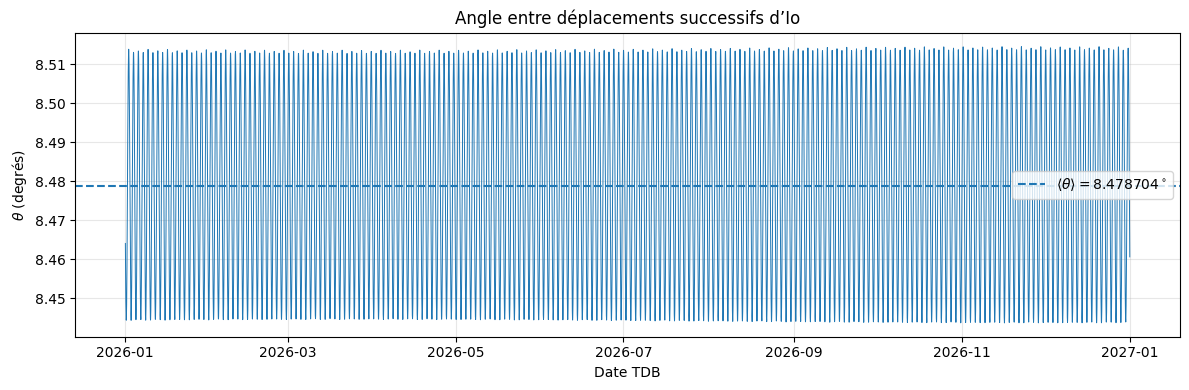

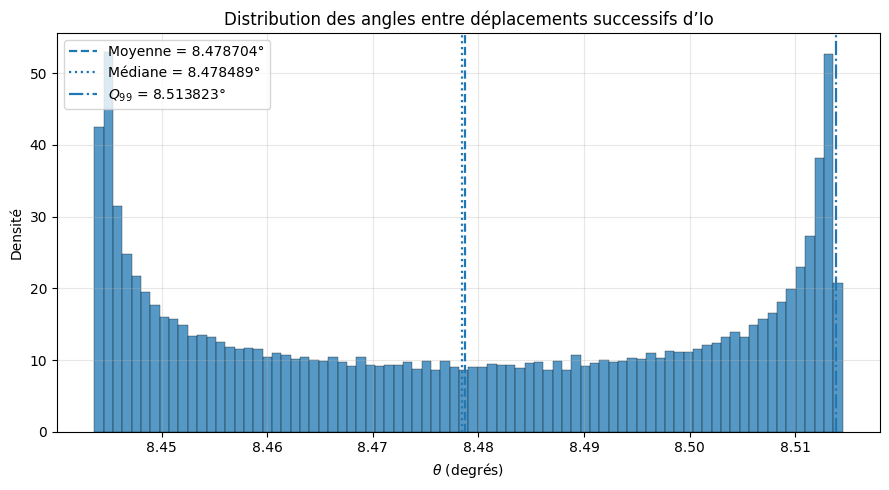

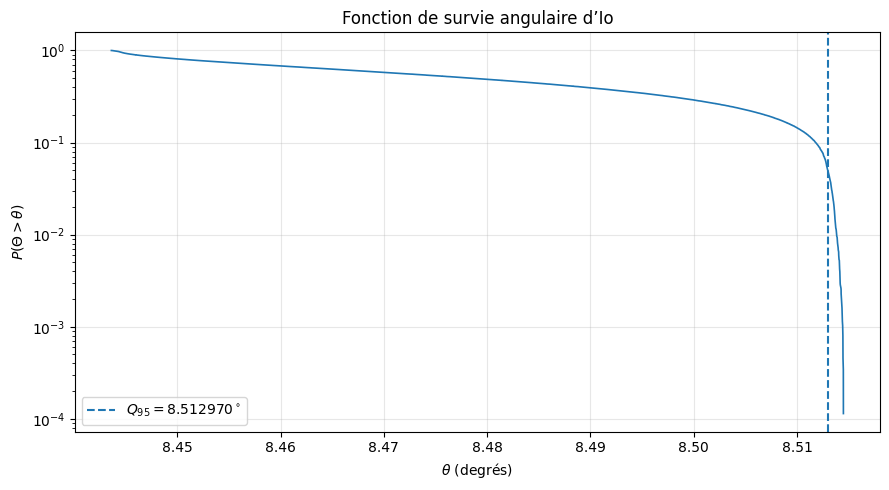


RÉSUMÉ DE L'ANALYSE ANGULAIRE — Io
Nombre d'angles                 : 8759
theta minimum                   : 8.443628078347 degrés
theta médian                    : 8.478489363646 degrés
theta Q90                       : 8.511796316605 degrés
theta Q95                       : 8.512969938072 degrés
theta Q99                       : 8.513823384342 degrés
theta moyen                     : 8.478703799352 degrés
theta écart-type                : 0.024558708820 degrés
theta maximum                   : 8.514491718621 degrés
theta_max / theta_mean          : 1.004220918682
theta_max - Q99                 : 0.000668334279 degrés
R_180 au seuil 175.0°       : 0.000000000000

Validation de l'analyse angulaire réussie.


In [ ]:
# ============================================================
# Étape 8 — Analyse angulaire des déplacements successifs
# ============================================================

# ------------------------------------------------------------
# 1. Vérification des incréments
# ------------------------------------------------------------

delta_R_io = np.asarray(delta_R_io, dtype=float)

if delta_R_io.ndim != 2 or delta_R_io.shape[1] != 3:
    raise ValueError(
        "delta_R_io doit avoir la forme (N, 3)."
    )

if len(delta_R_io) != len(R_io) - 1:
    raise ValueError(
        "Le nombre d'incréments doit être égal au nombre "
        "d'états moins un."
    )

if not np.isfinite(delta_R_io).all():
    raise ValueError(
        "delta_R_io contient des valeurs non finies."
    )


# ------------------------------------------------------------
# 2. Paires de déplacements successifs
# ------------------------------------------------------------

deplacement_1 = delta_R_io[:-1]
deplacement_2 = delta_R_io[1:]

norme_1 = np.linalg.norm(deplacement_1, axis=1)
norme_2 = np.linalg.norm(deplacement_2, axis=1)

if np.any(norme_1 == 0) or np.any(norme_2 == 0):
    raise ValueError(
        "Au moins un déplacement possède une norme nulle."
    )

produits_scalaires = np.einsum(
    "ij,ij->i",
    deplacement_1,
    deplacement_2
)

cos_theta = produits_scalaires / (norme_1 * norme_2)

# Protection contre les dépassements numériques de [-1, 1]
cos_theta_clipped = np.clip(cos_theta, -1.0, 1.0)

theta_rad = np.arccos(cos_theta_clipped)
theta_deg = np.degrees(theta_rad)


# ------------------------------------------------------------
# 3. Dates associées aux angles
# ------------------------------------------------------------

# L'angle au sommet R_(i+1) utilise les déplacements
# R_i -> R_(i+1) et R_(i+1) -> R_(i+2)
dates_theta = (
    io_state["Date_TDB"]
    .iloc[1:-1]
    .reset_index(drop=True)
)

if len(dates_theta) != len(theta_deg):
    raise RuntimeError(
        "La longueur des dates angulaires ne correspond "
        "pas au nombre d'angles."
    )


# ------------------------------------------------------------
# 4. Statistiques et quantiles
# ------------------------------------------------------------

theta_min = float(np.min(theta_deg))
theta_q01 = float(np.quantile(theta_deg, 0.01))
theta_q05 = float(np.quantile(theta_deg, 0.05))
theta_q25 = float(np.quantile(theta_deg, 0.25))
theta_q50 = float(np.quantile(theta_deg, 0.50))
theta_q75 = float(np.quantile(theta_deg, 0.75))
theta_q90 = float(np.quantile(theta_deg, 0.90))
theta_q95 = float(np.quantile(theta_deg, 0.95))
theta_q99 = float(np.quantile(theta_deg, 0.99))

theta_mean = float(np.mean(theta_deg))
theta_std = float(np.std(theta_deg, ddof=0))
theta_max = float(np.max(theta_deg))

rapport_theta_max_mean = (
    theta_max / theta_mean
    if theta_mean > 0
    else np.nan
)

max_moins_q99 = theta_max - theta_q99


# ------------------------------------------------------------
# 5. Inversions presque complètes
# ------------------------------------------------------------

seuil_R_180_deg = 175.0

mask_R_180 = theta_deg >= seuil_R_180_deg

N_R_180 = int(np.sum(mask_R_180))
R_180 = float(np.mean(mask_R_180))


# ------------------------------------------------------------
# 6. Tableau complet des angles
# ------------------------------------------------------------

io_angles = pd.DataFrame({
    "Date_TDB": dates_theta,
    "cos_theta": cos_theta_clipped,
    "theta_rad": theta_rad,
    "theta_deg": theta_deg,
    "R_180_event": mask_R_180,
})

print("=" * 90)
print("CONSTRUCTION DES ANGLES ENTRE DÉPLACEMENTS SUCCESSIFS")
print("=" * 90)

print(f"Nombre de déplacements          : {len(delta_R_io)}")
print(f"Nombre attendu d'angles         : {len(delta_R_io) - 1}")
print(f"Nombre obtenu d'angles          : {len(theta_deg)}")
print(f"Intervalle de cos(theta)        : "
      f"[{cos_theta_clipped.min():.12f}, "
      f"{cos_theta_clipped.max():.12f}]")


# ------------------------------------------------------------
# 7. Tableau des quantiles angulaires
# ------------------------------------------------------------

quantiles_angles_io = pd.DataFrame({
    "Observable": [
        "N_angles",
        "theta_min_deg",
        "theta_q01_deg",
        "theta_q05_deg",
        "theta_q25_deg",
        "theta_q50_deg",
        "theta_q75_deg",
        "theta_q90_deg",
        "theta_q95_deg",
        "theta_q99_deg",
        "theta_mean_deg",
        "theta_std_deg",
        "theta_max_deg",
        "rapport_theta_max_mean",
        "theta_max_moins_q99_deg",
        "Seuil_R_180_deg",
        "N_R_180",
        "R_180",
    ],
    "Valeur": [
        len(theta_deg),
        theta_min,
        theta_q01,
        theta_q05,
        theta_q25,
        theta_q50,
        theta_q75,
        theta_q90,
        theta_q95,
        theta_q99,
        theta_mean,
        theta_std,
        theta_max,
        rapport_theta_max_mean,
        max_moins_q99,
        seuil_R_180_deg,
        N_R_180,
        R_180,
    ]
})

print("\n" + "=" * 90)
print("OBSERVABLES ANGULAIRES — Io")
print("=" * 90)

display(quantiles_angles_io)


# ------------------------------------------------------------
# 8. Validation
# ------------------------------------------------------------

erreur_clipping_max = float(
    np.max(
        np.abs(cos_theta - cos_theta_clipped)
    )
)

validation_longueur_angles = (
    len(theta_deg) == len(delta_R_io) - 1
)

validation_angles_finis = np.isfinite(theta_deg).all()

validation_domaine_angles = (
    np.all(theta_deg >= 0.0)
    and np.all(theta_deg <= 180.0)
)

validation_cosinus = (
    np.all(cos_theta_clipped >= -1.0)
    and np.all(cos_theta_clipped <= 1.0)
)

controle_angles_io = pd.DataFrame({
    "Controle": [
        "Nombre de déplacements",
        "Nombre attendu d'angles",
        "Nombre obtenu d'angles",
        "Longueur angulaire cohérente",
        "Angles tous finis",
        "Angles compris entre 0 et 180 degrés",
        "Cosinus compris entre -1 et 1 après clipping",
        "Correction maximale due au clipping",
        "Nombre d'événements R_180",
    ],
    "Valeur": [
        len(delta_R_io),
        len(delta_R_io) - 1,
        len(theta_deg),
        validation_longueur_angles,
        validation_angles_finis,
        validation_domaine_angles,
        validation_cosinus,
        erreur_clipping_max,
        N_R_180,
    ]
})

print("\n" + "=" * 90)
print("VALIDATION DE L'ANALYSE ANGULAIRE")
print("=" * 90)

display(controle_angles_io)

print("\nPremiers angles :")
display(io_angles.head())


# ------------------------------------------------------------
# 9. Série temporelle angulaire
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(
    io_angles["Date_TDB"],
    io_angles["theta_deg"],
    linewidth=0.7,
)

plt.axhline(
    theta_mean,
    linestyle="--",
    linewidth=1.5,
    label=fr"$\langle\theta\rangle={theta_mean:.6f}^\circ$",
)

plt.xlabel("Date TDB")
plt.ylabel(r"$\theta$ (degrés)")
plt.title("Angle entre déplacements successifs d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Distribution angulaire
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    theta_deg,
    bins=80,
    density=True,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.75,
)

plt.axvline(
    theta_mean,
    linestyle="--",
    linewidth=1.6,
    label=fr"Moyenne = {theta_mean:.6f}°",
)

plt.axvline(
    theta_q50,
    linestyle=":",
    linewidth=1.6,
    label=fr"Médiane = {theta_q50:.6f}°",
)

plt.axvline(
    theta_q99,
    linestyle="-.",
    linewidth=1.6,
    label=fr"$Q_{{99}}$ = {theta_q99:.6f}°",
)

plt.xlabel(r"$\theta$ (degrés)")
plt.ylabel("Densité")
plt.title("Distribution des angles entre déplacements successifs d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Fonction de survie angulaire
# ------------------------------------------------------------

theta_sorted = np.sort(theta_deg)

R_theta = (
    len(theta_sorted)
    - np.arange(1, len(theta_sorted) + 1)
) / len(theta_sorted)

mask_theta_survie = R_theta > 0

plt.figure(figsize=(9, 5))

plt.semilogy(
    theta_sorted[mask_theta_survie],
    R_theta[mask_theta_survie],
    linewidth=1.2,
)

plt.axvline(
    theta_q95,
    linestyle="--",
    linewidth=1.5,
    label=fr"$Q_{{95}}={theta_q95:.6f}^\circ$",
)

plt.xlabel(r"$\theta$ (degrés)")
plt.ylabel(r"$P(\Theta>\theta)$")
plt.title("Fonction de survie angulaire d’Io")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. Résumé final
# ------------------------------------------------------------

validation_angulaire = all([
    validation_longueur_angles,
    validation_angles_finis,
    validation_domaine_angles,
    validation_cosinus,
])

print("\n" + "=" * 90)
print("RÉSUMÉ DE L'ANALYSE ANGULAIRE — Io")
print("=" * 90)

print(f"Nombre d'angles                 : {len(theta_deg)}")
print(f"theta minimum                   : {theta_min:.12f} degrés")
print(f"theta médian                    : {theta_q50:.12f} degrés")
print(f"theta Q90                       : {theta_q90:.12f} degrés")
print(f"theta Q95                       : {theta_q95:.12f} degrés")
print(f"theta Q99                       : {theta_q99:.12f} degrés")
print(f"theta moyen                     : {theta_mean:.12f} degrés")
print(f"theta écart-type                : {theta_std:.12f} degrés")
print(f"theta maximum                   : {theta_max:.12f} degrés")
print(f"theta_max / theta_mean          : "
      f"{rapport_theta_max_mean:.12f}")
print(f"theta_max - Q99                 : "
      f"{max_moins_q99:.12f} degrés")
print(f"R_180 au seuil {seuil_R_180_deg:.1f}°       : "
      f"{R_180:.12f}")

if validation_angulaire:
    print("\nValidation de l'analyse angulaire réussie.")
else:
    print("\nAttention : au moins un contrôle angulaire a échoué.")

### Résultat de l’analyse angulaire

L’analyse des \(8759\) angles entre déplacements successifs d’Io donne :

\[
\theta_{\mathrm{mean}}
=
8.478704^\circ,
\qquad
\sigma_\theta
=
0.024559^\circ.
\]

La distribution angulaire est extrêmement concentrée, avec :

\[
Q_{95}=8.512970^\circ,
\qquad
Q_{99}=8.513823^\circ,
\qquad
\theta_{\max}=8.514492^\circ.
\]

La faible différence :

\[
\theta_{\max}-Q_{99}
=
0.000668^\circ
\]

indique l’absence de queue angulaire extrême.

La période géométrique déduite de l’angle moyen horaire est :

\[
T_\theta
=
\frac{360^\circ}{\theta_{\mathrm{mean}}}
\approx
42.4593\ \mathrm{h}
\approx
1.76914\ \mathrm{jour}.
\]

Cette valeur montre que l’observable angulaire GVH retrouve directement l’échelle orbitale d’Io à partir de la succession locale des vecteurs de déplacement.

Enfin :

\[
R_{180}=0,
\]

ce qui confirme l’absence de retournements directionnels et la forte régularité géométrique de l’orbite jovicentrique d’Io.

## 9. Analyse fréquentielle FFT

L’analyse fréquentielle est appliquée aux coordonnées jovicentriques :

\[
X(t),\qquad Y(t),\qquad Z(t),\qquad r(t),
\]

ainsi qu’aux observables géométriques :

\[
D_T(t),\qquad \theta(t).
\]

Pour chaque signal \(s(t)\), on construit le signal centré :

\[
s_c(t)=s(t)-\langle s\rangle.
\]

Sa transformée de Fourier discrète réelle est :

\[
\widetilde{s}(f)
=
\operatorname{rFFT}[s_c(t)].
\]

Le spectre d’amplitude unilatéral est défini par :

\[
A(f)
=
\frac{2}{N}
\left|
\widetilde{s}(f)
\right|.
\]

La composante de fréquence nulle est exclue de la recherche des pics.  
La période associée à une fréquence dominante \(f_{\mathrm{pic}}\) est :

\[
T_{\mathrm{FFT}}
=
\frac{1}{f_{\mathrm{pic}}}.
\]

Les résultats sont exprimés en heures et en jours. Une interpolation
parabolique locale autour du maximum spectral est également utilisée
pour améliorer l’estimation de la fréquence dominante.

In [ ]:
def verifier_regularite_temporelle(
    dates,
    pas_attendu_heures=1.0,
    tolerance_secondes=1e-6,
):
    """
    Vérifie qu'une série de dates est régulièrement échantillonnée.

    Accepte :
    - pandas.Series
    - pandas.DatetimeIndex
    - liste ou tableau de dates
    """

    dates = pd.to_datetime(dates)

    if len(dates) < 2:
        raise ValueError(
            "Il faut au moins deux dates pour contrôler la régularité temporelle."
        )

    # Conversion robuste en Series, quel que soit le type d'entrée
    if isinstance(dates, pd.Series):
        dates_series = dates.reset_index(drop=True)
    else:
        dates_series = pd.Series(dates)

    delta_secondes = (
        dates_series
        .diff()
        .dropna()
        .dt.total_seconds()
        .to_numpy(dtype=float)
    )

    pas_attendu_secondes = float(
        pas_attendu_heures * 3600.0
    )

    erreur_absolue = np.abs(
        delta_secondes - pas_attendu_secondes
    )

    erreur_max = float(
        np.max(erreur_absolue)
    )

    reguliere = bool(
        erreur_max <= tolerance_secondes
    )

    return {
        "reguliere": reguliere,
        "pas_moyen_secondes": float(
            np.mean(delta_secondes)
        ),
        "pas_std_secondes": float(
            np.std(delta_secondes, ddof=0)
        ),
        "pas_min_secondes": float(
            np.min(delta_secondes)
        ),
        "pas_max_secondes": float(
            np.max(delta_secondes)
        ),
        "erreur_max_secondes": erreur_max,
        "nombre_intervalles": int(
            len(delta_secondes)
        ),
        "nombre_intervalles_irreguliers": int(
            np.sum(
                erreur_absolue
                > tolerance_secondes
            )
        ),
    }

ANALYSE FRÉQUENTIELLE FFT — Io

Analyse FFT en cours : X
  Période dominante interpolée : 42.507556172 h = 1.771148174 j

Analyse FFT en cours : Y
  Période dominante interpolée : 42.507370822 h = 1.771140451 j

Analyse FFT en cours : Z
  Période dominante interpolée : 42.507375576 h = 1.771140649 j

Analyse FFT en cours : r
  Période dominante interpolée : 42.322944579 h = 1.763456024 j

Analyse FFT en cours : D_T
  Période dominante interpolée : 42.318558135 h = 1.763273256 j

Analyse FFT en cours : theta
  Période dominante interpolée : 42.314043094 h = 1.763085129 j

RÉSUMÉ DES FRÉQUENCES DOMINANTES


,Signal,N,Duree_jours,Moyenne,Ecart_type,Frequence_pic_interp_cycles_jour,Periode_pic_interp_heures,Periode_pic_interp_jours,Amplitude_pic_interp,Resolution_cycles_jour,Regularite_temporelle,Erreur_temporelle_max_s
0,X,8761,365.000000,464.644729,298261.672379,0.564605,42.507556,1.771148,349006.096088,0.002739,True,0.0
1,Y,8761,365.000000,-507.156198,297988.366117,0.564608,42.507371,1.771140,348533.726672,0.002739,True,0.0
2,Z,8761,365.000000,-11.898897,11556.737040,0.564608,42.507376,1.771141,13514.000239,0.002739,True,0.0
3,r,8761,365.000000,421769.612104,1231.775994,0.567068,42.322945,1.763456,1718.540726,0.002739,True,0.0
4,D_T,8760,364.958333,62356.220153,182.102162,0.567127,42.318558,1.763273,255.625974,0.002740,True,0.0
5,theta,8759,364.916667,8.478704,0.024559,0.567188,42.314043,1.763085,0.034621,0.002740,True,0.0



PRINCIPAUX PICS SPECTRAUX


,Signal,Rang,Frequence_interp_cycles_jour,Periode_interp_heures,Periode_interp_jours,Amplitude_interp
0,X,1,0.564605,42.507556,1.771148,349006.096088
1,X,2,0.280056,85.697254,3.570719,1376.421990
2,X,3,0.140264,171.105661,7.129403,1085.525989
3,X,4,1.131559,21.209678,0.883737,860.470688
4,X,5,1.697357,14.139631,0.589151,239.621971
5,X,6,1.704283,14.082168,0.586757,235.973169
6,Y,1,0.564608,42.507371,1.771140,348533.726672
7,Y,2,1.130976,21.220605,0.884192,1218.965174
8,Y,3,0.279683,85.811539,3.575481,966.267413
9,Y,4,1.154348,20.790954,0.866290,648.805653


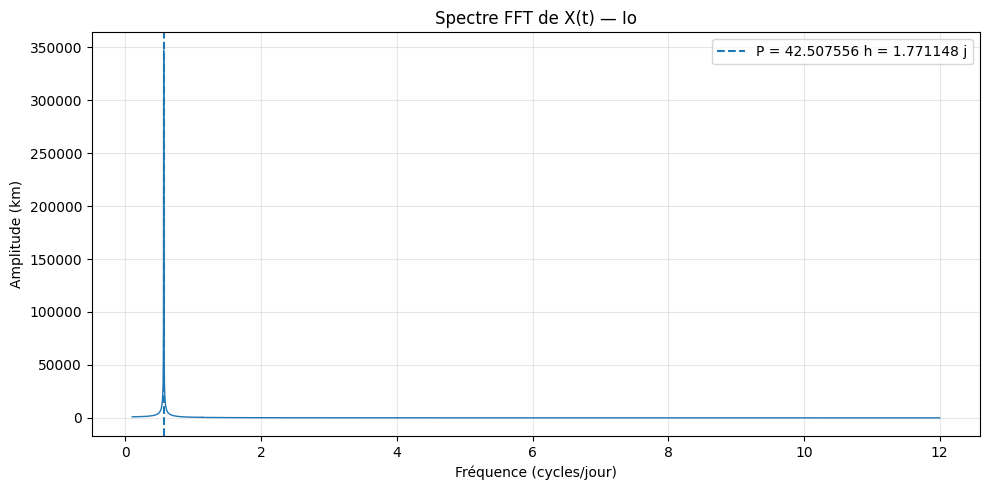

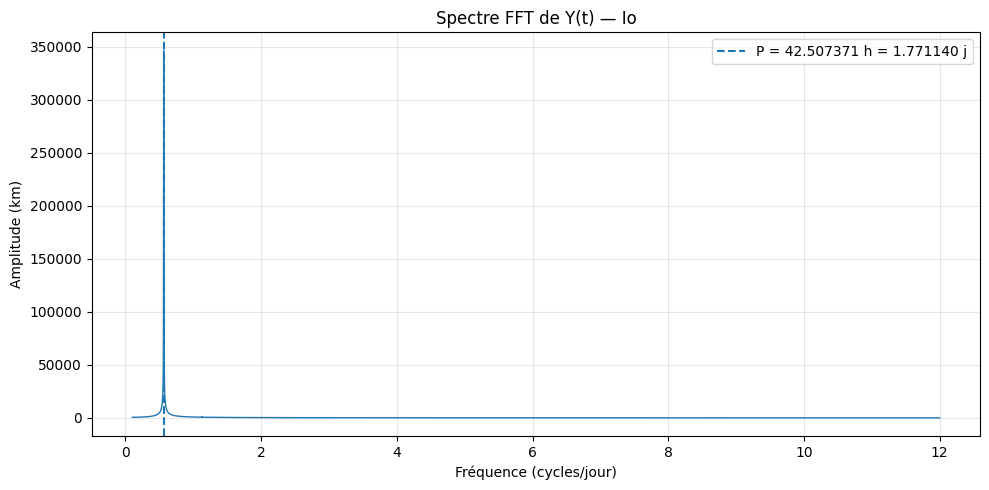

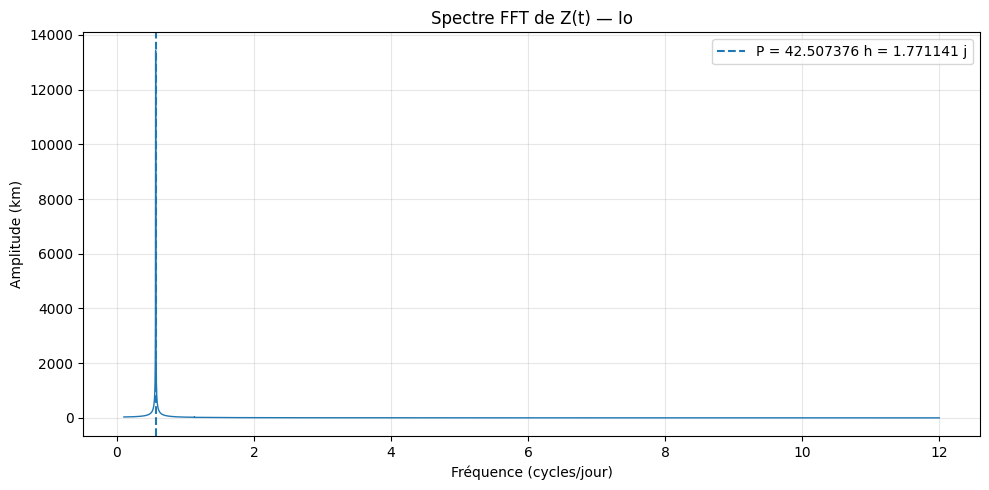

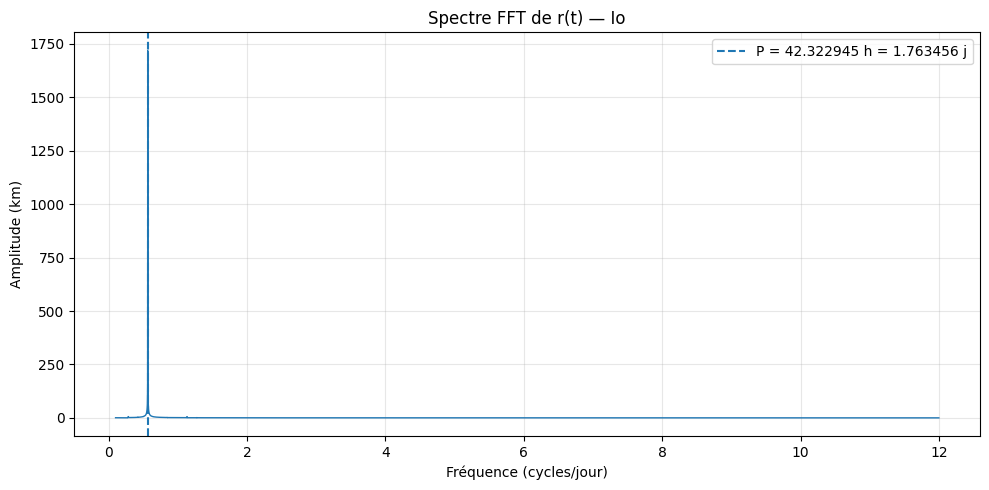

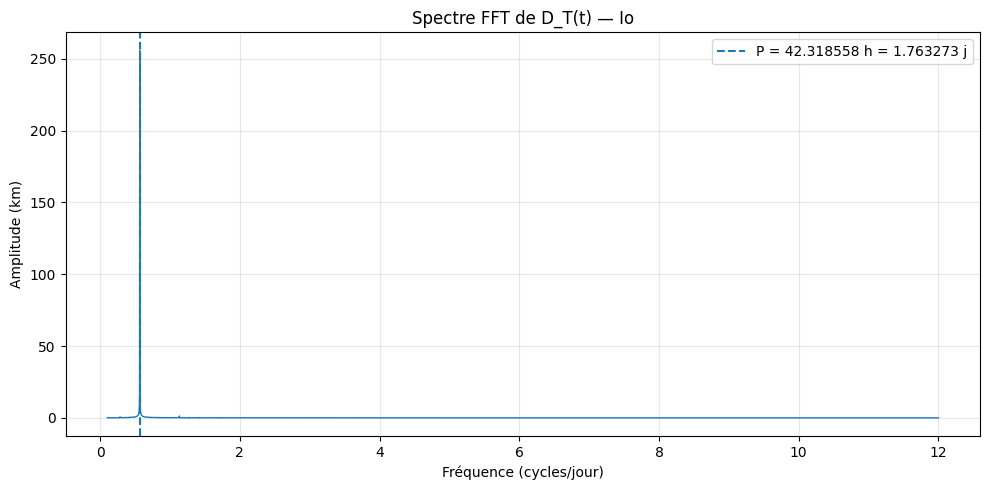

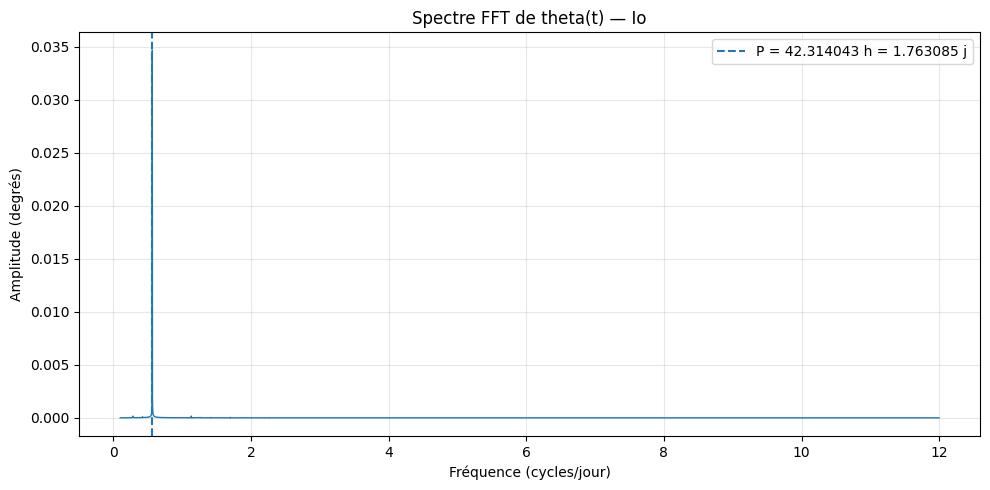

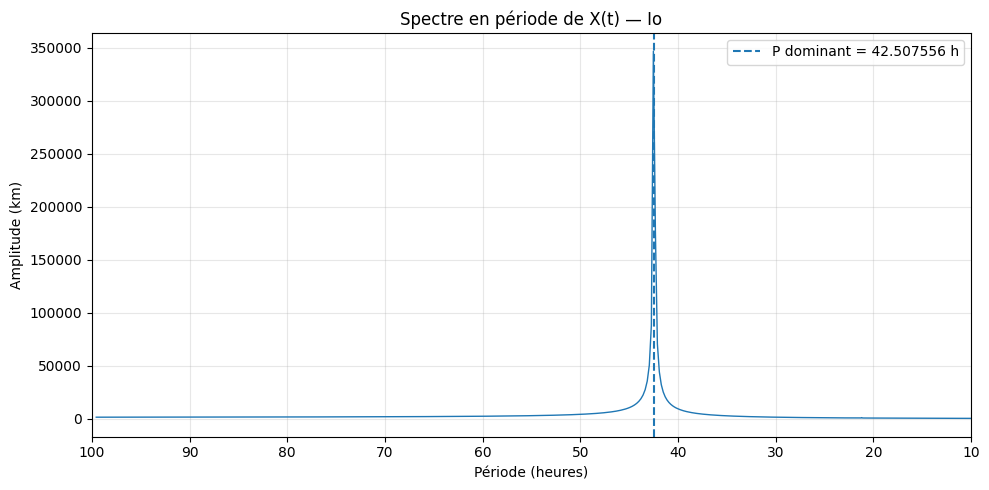

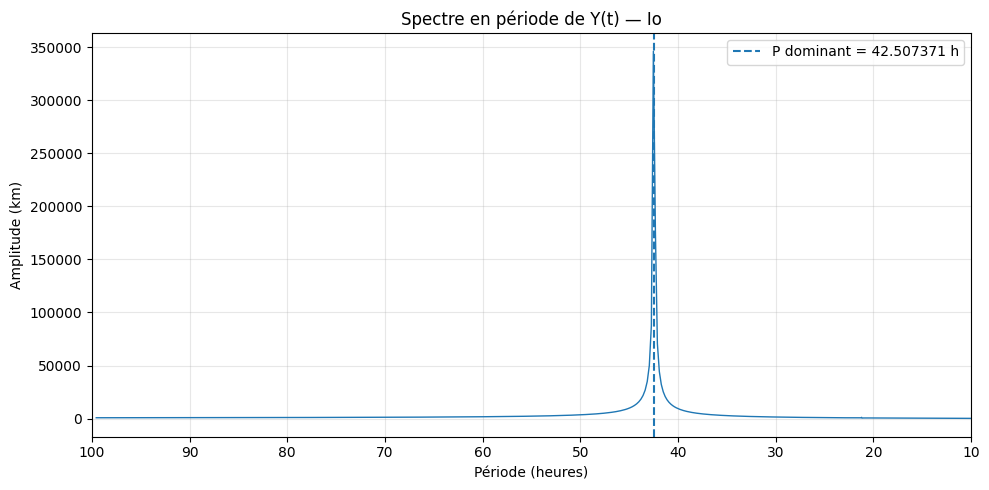

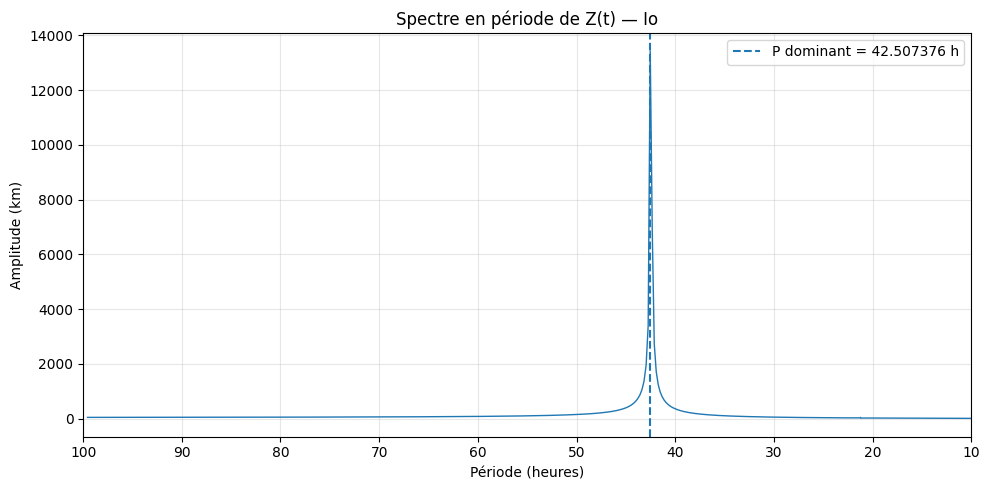

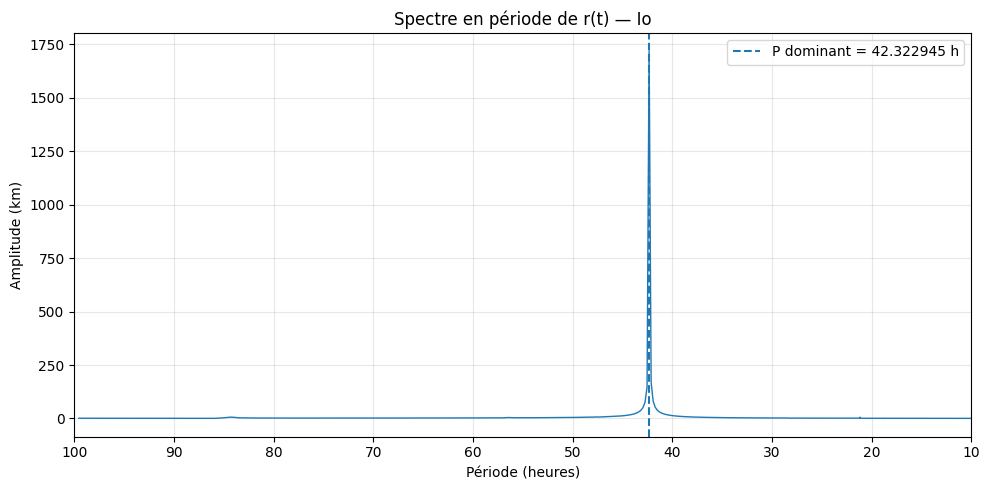

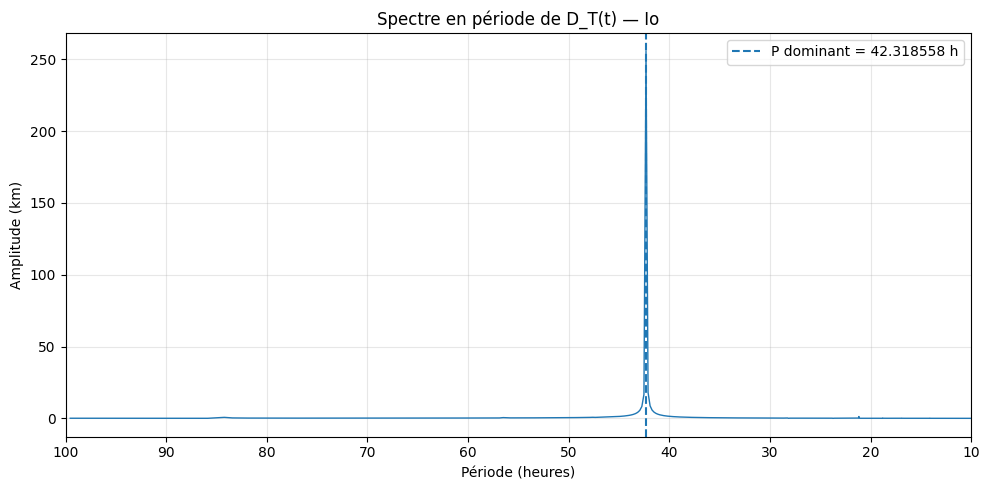

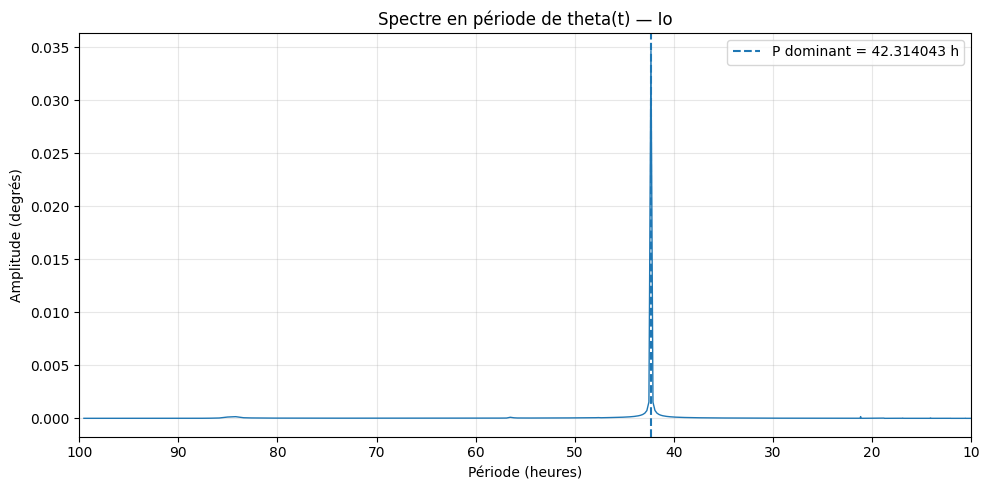


COMPARAISON AVEC LA PÉRIODE GÉOMÉTRIQUE ANGULAIRE
Période géométrique issue de theta_mean : 42.459320259 h = 1.769138344 j


,Signal,Periode_pic_interp_heures,Periode_pic_interp_jours,Ecart_a_periode_theta_heures,Ecart_relatif_a_periode_theta,Ecart_relatif_absolu_pct
0,X,42.507556,1.771148,0.048236,0.001136,0.113605
1,Y,42.507371,1.771140,0.048051,0.001132,0.113168
2,Z,42.507376,1.771141,0.048055,0.001132,0.113180
3,r,42.322945,1.763456,-0.136376,-0.003212,0.321191
4,D_T,42.318558,1.763273,-0.140762,-0.003315,0.331522
5,theta,42.314043,1.763085,-0.145277,-0.003422,0.342156



RAPPORTS HARMONIQUES PAR RAPPORT À X(t)


,Signal,Periode_pic_interp_heures,Frequence_relative_a_X,Harmonique_entier_proche,Ecart_harmonique
0,X,42.507556,1.000000,1,0.000000
1,Y,42.507371,1.000004,1,0.000004
2,Z,42.507376,1.000004,1,0.000004
3,r,42.322945,1.004362,1,0.004362
4,D_T,42.318558,1.004466,1,0.004466
5,theta,42.314043,1.004573,1,0.004573



VALIDATION DE L'ANALYSE FFT


,Signal,Serie_reguliere,Frequence_dominante_finie,Frequence_dominante_positive,Periode_dominante_finie,Periode_dominante_positive,Amplitude_dominante_positive,Validation_globale
0,X,True,True,True,True,True,True,True
1,Y,True,True,True,True,True,True,True
2,Z,True,True,True,True,True,True,True
3,r,True,True,True,True,True,True,True
4,D_T,True,True,True,True,True,True,True
5,theta,True,True,True,True,True,True,True



RÉSUMÉ FFT — Io
     X : P = 42.507556172 h = 1.771148174 j ; f = 0.564605500 cycles/j
     Y : P = 42.507370822 h = 1.771140451 j ; f = 0.564607962 cycles/j
     Z : P = 42.507375576 h = 1.771140649 j ; f = 0.564607899 cycles/j
     r : P = 42.322944579 h = 1.763456024 j ; f = 0.567068294 cycles/j
   D_T : P = 42.318558135 h = 1.763273256 j ; f = 0.567127073 cycles/j
 theta : P = 42.314043094 h = 1.763085129 j ; f = 0.567187587 cycles/j

Période géométrique issue de theta_mean : 42.459320259 h = 1.769138344 j

Validation de l'analyse FFT réussie.


In [16]:
# ============================================================
# Étape 9 — Analyse fréquentielle FFT d'Io
# X(t), Y(t), Z(t), r(t), D_T(t) et theta(t)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Paramètres généraux
# ------------------------------------------------------------

DT_HEURES = 1.0

PERIODE_MIN_HEURES = 2.0
PERIODE_MAX_HEURES = 24.0 * 100.0

N_PICS = 10

print("=" * 90)
print("ANALYSE FRÉQUENTIELLE FFT — Io")
print("=" * 90)


# ------------------------------------------------------------
# 2. Vérification des objets nécessaires
# ------------------------------------------------------------

objets_requis = [
    "io_state",
    "io_transitions",
    "io_angles",
]

objets_absents = [
    nom
    for nom in objets_requis
    if nom not in globals()
]

if objets_absents:
    raise NameError(
        "Objets absents avant l'analyse FFT : "
        + ", ".join(objets_absents)
    )


colonnes_etat_requises = [
    "Date_TDB",
    "X_km",
    "Y_km",
    "Z_km",
    "r_km",
]

colonnes_transition_requises = [
    "Date_milieu_TDB",
    "D_T_km",
]

colonnes_angle_requises = [
    "Date_TDB",
    "theta_deg",
]


for colonne in colonnes_etat_requises:
    if colonne not in io_state.columns:
        raise KeyError(
            f"Colonne absente de io_state : {colonne}"
        )

for colonne in colonnes_transition_requises:
    if colonne not in io_transitions.columns:
        raise KeyError(
            f"Colonne absente de io_transitions : {colonne}"
        )

for colonne in colonnes_angle_requises:
    if colonne not in io_angles.columns:
        raise KeyError(
            f"Colonne absente de io_angles : {colonne}"
        )


# ------------------------------------------------------------
# 3. Préparation des séries
# ------------------------------------------------------------

series_fft_io = {
    "X": {
        "temps": pd.to_datetime(
            io_state["Date_TDB"]
        ),
        "signal": io_state["X_km"].to_numpy(
            dtype=float
        ),
        "unite": "km",
    },

    "Y": {
        "temps": pd.to_datetime(
            io_state["Date_TDB"]
        ),
        "signal": io_state["Y_km"].to_numpy(
            dtype=float
        ),
        "unite": "km",
    },

    "Z": {
        "temps": pd.to_datetime(
            io_state["Date_TDB"]
        ),
        "signal": io_state["Z_km"].to_numpy(
            dtype=float
        ),
        "unite": "km",
    },

    "r": {
        "temps": pd.to_datetime(
            io_state["Date_TDB"]
        ),
        "signal": io_state["r_km"].to_numpy(
            dtype=float
        ),
        "unite": "km",
    },

    "D_T": {
        "temps": pd.to_datetime(
            io_transitions["Date_milieu_TDB"]
        ),
        "signal": io_transitions["D_T_km"].to_numpy(
            dtype=float
        ),
        "unite": "km",
    },

    "theta": {
        "temps": pd.to_datetime(
            io_angles["Date_TDB"]
        ),
        "signal": io_angles["theta_deg"].to_numpy(
            dtype=float
        ),
        "unite": "degrés",
    },
}


# ------------------------------------------------------------
# 4. Contrôle de la régularité temporelle
# ------------------------------------------------------------

def verifier_regularite_temporelle(
    dates,
    pas_attendu_heures=1.0,
    tolerance_secondes=1e-6,
):
    """
    Vérifie qu'une série temporelle est régulièrement échantillonnée.

    Types acceptés :
    - pandas.Series
    - pandas.DatetimeIndex
    - numpy.ndarray
    - liste Python
    """

    dates_converties = pd.to_datetime(
        dates,
        errors="coerce",
    )

    if isinstance(dates_converties, pd.Series):
        dates_series = (
            dates_converties
            .reset_index(drop=True)
        )
    else:
        dates_series = pd.Series(
            dates_converties
        )

    if len(dates_series) < 2:
        raise ValueError(
            "Il faut au moins deux dates pour contrôler "
            "la régularité temporelle."
        )

    if dates_series.isna().any():
        raise ValueError(
            "La série temporelle contient des dates invalides."
        )

    delta_secondes = (
        dates_series
        .diff()
        .dropna()
        .dt.total_seconds()
        .to_numpy(dtype=float)
    )

    if len(delta_secondes) == 0:
        raise ValueError(
            "Aucun intervalle temporel n'a pu être calculé."
        )

    pas_attendu_secondes = float(
        pas_attendu_heures * 3600.0
    )

    erreurs = np.abs(
        delta_secondes
        - pas_attendu_secondes
    )

    erreur_max = float(
        np.max(erreurs)
    )

    nombre_irreguliers = int(
        np.sum(
            erreurs > tolerance_secondes
        )
    )

    reguliere = bool(
        nombre_irreguliers == 0
    )

    return {
        "reguliere": reguliere,
        "nombre_dates": int(
            len(dates_series)
        ),
        "nombre_intervalles": int(
            len(delta_secondes)
        ),
        "pas_attendu_secondes": (
            pas_attendu_secondes
        ),
        "pas_moyen_secondes": float(
            np.mean(delta_secondes)
        ),
        "pas_std_secondes": float(
            np.std(
                delta_secondes,
                ddof=0,
            )
        ),
        "pas_min_secondes": float(
            np.min(delta_secondes)
        ),
        "pas_max_secondes": float(
            np.max(delta_secondes)
        ),
        "erreur_max_secondes": erreur_max,
        "nombre_intervalles_irreguliers": (
            nombre_irreguliers
        ),
    }


# ------------------------------------------------------------
# 5. Interpolation parabolique d'un pic spectral
# ------------------------------------------------------------

def interpolation_parabolique_pic(
    frequences,
    amplitudes,
    indice_pic,
):
    """
    Améliore l'estimation de la fréquence dominante
    par interpolation quadratique locale.
    """

    frequences = np.asarray(
        frequences,
        dtype=float,
    )

    amplitudes = np.asarray(
        amplitudes,
        dtype=float,
    )

    indice_pic = int(
        indice_pic
    )

    if indice_pic <= 0:
        return (
            float(frequences[indice_pic]),
            float(amplitudes[indice_pic]),
            0.0,
        )

    if indice_pic >= len(amplitudes) - 1:
        return (
            float(frequences[indice_pic]),
            float(amplitudes[indice_pic]),
            0.0,
        )

    y_gauche = float(
        amplitudes[indice_pic - 1]
    )

    y_centre = float(
        amplitudes[indice_pic]
    )

    y_droite = float(
        amplitudes[indice_pic + 1]
    )

    denominateur = (
        y_gauche
        - 2.0 * y_centre
        + y_droite
    )

    if np.isclose(
        denominateur,
        0.0,
    ):
        decalage = 0.0
    else:
        decalage = (
            0.5
            * (y_gauche - y_droite)
            / denominateur
        )

    decalage = float(
        np.clip(
            decalage,
            -1.0,
            1.0,
        )
    )

    pas_frequence = float(
        frequences[1]
        - frequences[0]
    )

    frequence_interpolee = float(
        frequences[indice_pic]
        + decalage * pas_frequence
    )

    amplitude_interpolee = float(
        y_centre
        - 0.25
        * (y_gauche - y_droite)
        * decalage
    )

    return (
        frequence_interpolee,
        amplitude_interpolee,
        decalage,
    )


# ------------------------------------------------------------
# 6. Détection des pics locaux
# ------------------------------------------------------------

def indices_pics_locaux(
    amplitudes,
):
    amplitudes = np.asarray(
        amplitudes,
        dtype=float,
    )

    if len(amplitudes) < 3:
        return np.array(
            [],
            dtype=int,
        )

    indices = np.where(
        (
            amplitudes[1:-1]
            > amplitudes[:-2]
        )
        & (
            amplitudes[1:-1]
            >= amplitudes[2:]
        )
    )[0] + 1

    return indices.astype(int)


# ------------------------------------------------------------
# 7. Fonction principale FFT
# ------------------------------------------------------------

def analyser_fft(
    nom_signal,
    signal,
    dates,
    unite,
    dt_heures=1.0,
    periode_min_heures=2.0,
    periode_max_heures=2400.0,
    n_pics=10,
):
    signal = np.asarray(
        signal,
        dtype=float,
    )

    dates = pd.to_datetime(
        dates,
        errors="coerce",
    )

    if signal.ndim != 1:
        raise ValueError(
            f"{nom_signal} doit être une série 1D."
        )

    if len(signal) != len(dates):
        raise ValueError(
            f"Longueurs incompatibles pour {nom_signal} : "
            f"{len(signal)} valeurs et {len(dates)} dates."
        )

    if len(signal) < 8:
        raise ValueError(
            f"La série {nom_signal} est trop courte pour une FFT."
        )

    if not np.isfinite(signal).all():
        raise ValueError(
            f"La série {nom_signal} contient des valeurs non finies."
        )

    controle_temps = verifier_regularite_temporelle(
        dates=dates,
        pas_attendu_heures=dt_heures,
        tolerance_secondes=1e-6,
    )

    if not controle_temps["reguliere"]:
        raise ValueError(
            f"La série {nom_signal} n'est pas régulièrement "
            "échantillonnée."
        )

    N = int(
        len(signal)
    )

    moyenne = float(
        np.mean(signal)
    )

    ecart_type = float(
        np.std(
            signal,
            ddof=0,
        )
    )

    signal_centre = (
        signal - moyenne
    )

    # Fenêtre rectangulaire
    fenetre = np.ones(
        N,
        dtype=float,
    )

    signal_fenetre = (
        signal_centre
        * fenetre
    )

    fft_complexe = np.fft.rfft(
        signal_fenetre
    )

    frequences_h = np.fft.rfftfreq(
        N,
        d=dt_heures,
    )

    amplitudes = (
        2.0
        * np.abs(fft_complexe)
        / np.sum(fenetre)
    )

    # Suppression de la composante continue
    amplitudes[0] = 0.0

    frequences_jour = (
        frequences_h * 24.0
    )

    periodes_heures = np.full(
        len(frequences_h),
        np.inf,
        dtype=float,
    )

    masque_frequence_positive = (
        frequences_h > 0
    )

    periodes_heures[
        masque_frequence_positive
    ] = (
        1.0
        / frequences_h[
            masque_frequence_positive
        ]
    )

    periodes_jours = (
        periodes_heures / 24.0
    )

    masque_domaine = (
        (frequences_h > 0)
        & (
            periodes_heures
            >= periode_min_heures
        )
        & (
            periodes_heures
            <= periode_max_heures
        )
    )

    indices_domaine = np.where(
        masque_domaine
    )[0]

    if len(indices_domaine) == 0:
        raise RuntimeError(
            f"Aucune fréquence admissible pour {nom_signal}."
        )

    indice_dominant = int(
        indices_domaine[
            np.argmax(
                amplitudes[
                    indices_domaine
                ]
            )
        ]
    )

    (
        frequence_pic_interp_h,
        amplitude_pic_interp,
        decalage_pic,
    ) = interpolation_parabolique_pic(
        frequences=frequences_h,
        amplitudes=amplitudes,
        indice_pic=indice_dominant,
    )

    if frequence_pic_interp_h > 0:
        periode_pic_interp_heures = float(
            1.0
            / frequence_pic_interp_h
        )

        periode_pic_interp_jours = float(
            periode_pic_interp_heures
            / 24.0
        )
    else:
        periode_pic_interp_heures = np.nan
        periode_pic_interp_jours = np.nan

    resolution_f_h = float(
        frequences_h[1]
        - frequences_h[0]
    )

    resolution_f_jour = float(
        resolution_f_h * 24.0
    )


    # --------------------------------------------------------
    # Recherche des pics locaux
    # --------------------------------------------------------

    pics_locaux = indices_pics_locaux(
        amplitudes
    )

    if len(pics_locaux) > 0:
        pics_locaux = pics_locaux[
            masque_domaine[pics_locaux]
        ]

    if len(pics_locaux) == 0:
        pics_locaux = np.array(
            [indice_dominant],
            dtype=int,
        )

    ordre_pics = np.argsort(
        amplitudes[pics_locaux]
    )[::-1]

    pics_locaux = pics_locaux[
        ordre_pics
    ][:n_pics]

    lignes_pics = []

    for rang, indice in enumerate(
        pics_locaux,
        start=1,
    ):
        (
            f_interp_h,
            amp_interp,
            decalage,
        ) = interpolation_parabolique_pic(
            frequences=frequences_h,
            amplitudes=amplitudes,
            indice_pic=int(indice),
        )

        if f_interp_h > 0:
            periode_interp_h = float(
                1.0 / f_interp_h
            )

            periode_interp_j = float(
                periode_interp_h / 24.0
            )
        else:
            periode_interp_h = np.nan
            periode_interp_j = np.nan

        lignes_pics.append({
            "Signal": nom_signal,
            "Rang": rang,
            "Indice_FFT": int(indice),

            "Frequence_brute_cycles_h": float(
                frequences_h[indice]
            ),

            "Frequence_brute_cycles_jour": float(
                frequences_jour[indice]
            ),

            "Periode_brute_heures": float(
                periodes_heures[indice]
            ),

            "Periode_brute_jours": float(
                periodes_jours[indice]
            ),

            "Amplitude_brute": float(
                amplitudes[indice]
            ),

            "Frequence_interp_cycles_h": float(
                f_interp_h
            ),

            "Frequence_interp_cycles_jour": float(
                f_interp_h * 24.0
            ),

            "Periode_interp_heures": (
                periode_interp_h
            ),

            "Periode_interp_jours": (
                periode_interp_j
            ),

            "Amplitude_interp": float(
                amp_interp
            ),

            "Decalage_parabolique": float(
                decalage
            ),
        })

    tableau_pics = pd.DataFrame(
        lignes_pics
    )

    spectre = pd.DataFrame({
        "Signal": nom_signal,
        "Frequence_cycles_h": (
            frequences_h
        ),
        "Frequence_cycles_jour": (
            frequences_jour
        ),
        "Periode_heures": (
            periodes_heures
        ),
        "Periode_jours": (
            periodes_jours
        ),
        "Amplitude": amplitudes,
    })

    resume = {
        "Signal": nom_signal,
        "Unite": unite,
        "N": N,

        "Duree_heures": float(
            (N - 1) * dt_heures
        ),

        "Duree_jours": float(
            (N - 1)
            * dt_heures
            / 24.0
        ),

        "Pas_heures": float(
            dt_heures
        ),

        "Moyenne": moyenne,
        "Ecart_type": ecart_type,

        "Resolution_cycles_h": (
            resolution_f_h
        ),

        "Resolution_cycles_jour": (
            resolution_f_jour
        ),

        "Frequence_pic_brute_cycles_h": float(
            frequences_h[indice_dominant]
        ),

        "Frequence_pic_brute_cycles_jour": float(
            frequences_jour[indice_dominant]
        ),

        "Periode_pic_brute_heures": float(
            periodes_heures[indice_dominant]
        ),

        "Periode_pic_brute_jours": float(
            periodes_jours[indice_dominant]
        ),

        "Amplitude_pic_brute": float(
            amplitudes[indice_dominant]
        ),

        "Frequence_pic_interp_cycles_h": float(
            frequence_pic_interp_h
        ),

        "Frequence_pic_interp_cycles_jour": float(
            frequence_pic_interp_h
            * 24.0
        ),

        "Periode_pic_interp_heures": (
            periode_pic_interp_heures
        ),

        "Periode_pic_interp_jours": (
            periode_pic_interp_jours
        ),

        "Amplitude_pic_interp": float(
            amplitude_pic_interp
        ),

        "Decalage_parabolique": float(
            decalage_pic
        ),

        "Regularite_temporelle": bool(
            controle_temps["reguliere"]
        ),

        "Erreur_temporelle_max_s": float(
            controle_temps[
                "erreur_max_secondes"
            ]
        ),
    }

    return {
        "resume": resume,
        "spectre": spectre,
        "pics": tableau_pics,
        "signal_centre": signal_centre,
        "frequences_h": frequences_h,
        "amplitudes": amplitudes,
        "indice_dominant": indice_dominant,
        "controle_temps": controle_temps,
    }


# ------------------------------------------------------------
# 8. Exécution sur les six séries
# ------------------------------------------------------------

resultats_fft_io = {}
resumes_fft = []
tableaux_pics = []

for nom_signal, donnees in series_fft_io.items():

    print(
        f"\nAnalyse FFT en cours : {nom_signal}"
    )

    resultat = analyser_fft(
        nom_signal=nom_signal,
        signal=donnees["signal"],
        dates=donnees["temps"],
        unite=donnees["unite"],
        dt_heures=DT_HEURES,
        periode_min_heures=PERIODE_MIN_HEURES,
        periode_max_heures=PERIODE_MAX_HEURES,
        n_pics=N_PICS,
    )

    resultats_fft_io[
        nom_signal
    ] = resultat

    resumes_fft.append(
        resultat["resume"]
    )

    tableaux_pics.append(
        resultat["pics"]
    )

    print(
        "  Période dominante interpolée : "
        f"{resultat['resume']['Periode_pic_interp_heures']:.9f} h "
        f"= "
        f"{resultat['resume']['Periode_pic_interp_jours']:.9f} j"
    )


resume_fft_io = pd.DataFrame(
    resumes_fft
)

pics_fft_io = pd.concat(
    tableaux_pics,
    ignore_index=True,
)


# ------------------------------------------------------------
# 9. Résumé des fréquences dominantes
# ------------------------------------------------------------

colonnes_resume_affichage = [
    "Signal",
    "N",
    "Duree_jours",
    "Moyenne",
    "Ecart_type",
    "Frequence_pic_interp_cycles_jour",
    "Periode_pic_interp_heures",
    "Periode_pic_interp_jours",
    "Amplitude_pic_interp",
    "Resolution_cycles_jour",
    "Regularite_temporelle",
    "Erreur_temporelle_max_s",
]

print("\n" + "=" * 90)
print("RÉSUMÉ DES FRÉQUENCES DOMINANTES")
print("=" * 90)

display(
    resume_fft_io[
        colonnes_resume_affichage
    ]
)


# ------------------------------------------------------------
# 10. Principaux pics spectraux
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("PRINCIPAUX PICS SPECTRAUX")
print("=" * 90)

display(
    pics_fft_io[
        [
            "Signal",
            "Rang",
            "Frequence_interp_cycles_jour",
            "Periode_interp_heures",
            "Periode_interp_jours",
            "Amplitude_interp",
        ]
    ]
)


# ------------------------------------------------------------
# 11. Spectres en fréquence
# ------------------------------------------------------------

for nom_signal in [
    "X",
    "Y",
    "Z",
    "r",
    "D_T",
    "theta",
]:
    resultat = resultats_fft_io[
        nom_signal
    ]

    spectre = resultat[
        "spectre"
    ]

    resume = resultat[
        "resume"
    ]

    masque_plot = (
        np.isfinite(
            spectre["Periode_heures"]
        )
        & (
            spectre["Periode_heures"]
            >= PERIODE_MIN_HEURES
        )
        & (
            spectre["Periode_heures"]
            <= 240.0
        )
    )

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        spectre.loc[
            masque_plot,
            "Frequence_cycles_jour"
        ],
        spectre.loc[
            masque_plot,
            "Amplitude"
        ],
        linewidth=1.0,
    )

    plt.axvline(
        resume[
            "Frequence_pic_interp_cycles_jour"
        ],
        linestyle="--",
        linewidth=1.5,
        label=(
            f"P = "
            f"{resume['Periode_pic_interp_heures']:.6f} h "
            f"= "
            f"{resume['Periode_pic_interp_jours']:.6f} j"
        ),
    )

    plt.xlabel(
        "Fréquence (cycles/jour)"
    )

    plt.ylabel(
        f"Amplitude ({resume['Unite']})"
    )

    plt.title(
        f"Spectre FFT de {nom_signal}(t) — Io"
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# 12. Spectres en fonction de la période
# ------------------------------------------------------------

for nom_signal in [
    "X",
    "Y",
    "Z",
    "r",
    "D_T",
    "theta",
]:
    spectre = resultats_fft_io[
        nom_signal
    ]["spectre"]

    resume = resultats_fft_io[
        nom_signal
    ]["resume"]

    masque_periode = (
        np.isfinite(
            spectre["Periode_heures"]
        )
        & (
            spectre["Periode_heures"]
            >= 10.0
        )
        & (
            spectre["Periode_heures"]
            <= 100.0
        )
    )

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        spectre.loc[
            masque_periode,
            "Periode_heures"
        ],
        spectre.loc[
            masque_periode,
            "Amplitude"
        ],
        linewidth=1.0,
    )

    plt.axvline(
        resume[
            "Periode_pic_interp_heures"
        ],
        linestyle="--",
        linewidth=1.5,
        label=(
            f"P dominant = "
            f"{resume['Periode_pic_interp_heures']:.6f} h"
        ),
    )

    plt.xlabel(
        "Période (heures)"
    )

    plt.ylabel(
        f"Amplitude ({resume['Unite']})"
    )

    plt.title(
        f"Spectre en période de {nom_signal}(t) — Io"
    )

    plt.xlim(
        100.0,
        10.0,
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# 13. Période géométrique issue de theta_mean
# ------------------------------------------------------------

if "theta_mean" not in globals():
    theta_mean = float(
        np.mean(
            io_angles["theta_deg"]
        )
    )

periode_theta_geometrique_h = float(
    360.0 / theta_mean
)

periode_theta_geometrique_j = float(
    periode_theta_geometrique_h
    / 24.0
)


comparaison_periodes_io = (
    resume_fft_io[
        [
            "Signal",
            "Periode_pic_interp_heures",
            "Periode_pic_interp_jours",
        ]
    ]
    .copy()
)

comparaison_periodes_io[
    "Ecart_a_periode_theta_heures"
] = (
    comparaison_periodes_io[
        "Periode_pic_interp_heures"
    ]
    - periode_theta_geometrique_h
)

comparaison_periodes_io[
    "Ecart_relatif_a_periode_theta"
] = (
    comparaison_periodes_io[
        "Ecart_a_periode_theta_heures"
    ]
    / periode_theta_geometrique_h
)

comparaison_periodes_io[
    "Ecart_relatif_absolu_pct"
] = (
    100.0
    * np.abs(
        comparaison_periodes_io[
            "Ecart_relatif_a_periode_theta"
        ]
    )
)

print("\n" + "=" * 90)
print("COMPARAISON AVEC LA PÉRIODE GÉOMÉTRIQUE ANGULAIRE")
print("=" * 90)

print(
    "Période géométrique issue de theta_mean : "
    f"{periode_theta_geometrique_h:.9f} h "
    f"= "
    f"{periode_theta_geometrique_j:.9f} j"
)

display(
    comparaison_periodes_io
)


# ------------------------------------------------------------
# 14. Rapports harmoniques
# ------------------------------------------------------------

periode_reference_h = float(
    resume_fft_io.loc[
        resume_fft_io["Signal"] == "X",
        "Periode_pic_interp_heures"
    ].iloc[0]
)

comparaison_harmoniques_io = (
    resume_fft_io[
        [
            "Signal",
            "Periode_pic_interp_heures",
        ]
    ]
    .copy()
)

comparaison_harmoniques_io[
    "Frequence_relative_a_X"
] = (
    periode_reference_h
    / comparaison_harmoniques_io[
        "Periode_pic_interp_heures"
    ]
)

comparaison_harmoniques_io[
    "Harmonique_entier_proche"
] = np.rint(
    comparaison_harmoniques_io[
        "Frequence_relative_a_X"
    ]
).astype(int)

comparaison_harmoniques_io[
    "Ecart_harmonique"
] = (
    comparaison_harmoniques_io[
        "Frequence_relative_a_X"
    ]
    - comparaison_harmoniques_io[
        "Harmonique_entier_proche"
    ]
)

print("\n" + "=" * 90)
print("RAPPORTS HARMONIQUES PAR RAPPORT À X(t)")
print("=" * 90)

display(
    comparaison_harmoniques_io
)


# ------------------------------------------------------------
# 15. Validation finale
# ------------------------------------------------------------

validations_fft = []

for nom_signal in series_fft_io.keys():

    resume = resultats_fft_io[
        nom_signal
    ]["resume"]

    validation = {
        "Signal": nom_signal,

        "Serie_reguliere": bool(
            resume[
                "Regularite_temporelle"
            ]
        ),

        "Frequence_dominante_finie": bool(
            np.isfinite(
                resume[
                    "Frequence_pic_interp_cycles_h"
                ]
            )
        ),

        "Frequence_dominante_positive": bool(
            resume[
                "Frequence_pic_interp_cycles_h"
            ] > 0
        ),

        "Periode_dominante_finie": bool(
            np.isfinite(
                resume[
                    "Periode_pic_interp_heures"
                ]
            )
        ),

        "Periode_dominante_positive": bool(
            resume[
                "Periode_pic_interp_heures"
            ] > 0
        ),

        "Amplitude_dominante_positive": bool(
            resume[
                "Amplitude_pic_interp"
            ] > 0
        ),
    }

    validation[
        "Validation_globale"
    ] = all(
        valeur
        for cle, valeur
        in validation.items()
        if cle != "Signal"
    )

    validations_fft.append(
        validation
    )


controle_fft_io = pd.DataFrame(
    validations_fft
)

print("\n" + "=" * 90)
print("VALIDATION DE L'ANALYSE FFT")
print("=" * 90)

display(
    controle_fft_io
)

validation_fft_globale = bool(
    controle_fft_io[
        "Validation_globale"
    ].all()
)


# ------------------------------------------------------------
# 16. Résumé final
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("RÉSUMÉ FFT — Io")
print("=" * 90)

for _, ligne in resume_fft_io.iterrows():

    print(
        f"{ligne['Signal']:>6s} : "
        f"P = "
        f"{ligne['Periode_pic_interp_heures']:.9f} h "
        f"= "
        f"{ligne['Periode_pic_interp_jours']:.9f} j ; "
        f"f = "
        f"{ligne['Frequence_pic_interp_cycles_jour']:.9f} cycles/j"
    )

print(
    "\nPériode géométrique issue de theta_mean : "
    f"{periode_theta_geometrique_h:.9f} h "
    f"= "
    f"{periode_theta_geometrique_j:.9f} j"
)

if validation_fft_globale:
    print(
        "\nValidation de l'analyse FFT réussie."
    )
else:
    print(
        "\nAttention : au moins une validation FFT a échoué."
    )

### Résultat de l’analyse fréquentielle

L’analyse FFT des coordonnées jovicentriques d’Io fait apparaître une
fréquence orbitale dominante commune à \(X(t)\), \(Y(t)\) et \(Z(t)\) :

\[
\bar T_{XYZ}\approx 42.5074\ \mathrm{h}
\approx 1.77114\ \mathrm{jour}.
\]

Les observables géométriques dérivées \(r(t)\), \(D_T(t)\) et
\(\theta(t)\) forment une seconde famille cohérente :

\[
\bar T_{\mathrm{local}}
\approx 42.3185\ \mathrm{h}
\approx 1.76327\ \mathrm{jour}.
\]

La différence entre les deux familles vaut approximativement :

\[
\Delta T\approx 0.189\ \mathrm{h}
\approx 11.3\ \mathrm{min}.
\]

Elle correspond formellement à une échelle de battement proche de
\(397\) jours. Cette échelle reste cependant comparable à la durée
totale de la série et la séparation fréquentielle est légèrement
inférieure à la résolution brute de la FFT. Elle doit donc être
considérée comme une structure candidate à vérifier, et non encore
comme une période physique indépendante.

Les spectres révèlent également des composantes proches de \(T/2\),
\(2T\) et \(T/3\), compatibles avec une structure harmonique et avec
les non-linéarités introduites par les observables \(r\), \(D_T\) et
\(\theta\).

L’analyse confirme ainsi que les observables GVH conservent
l’information orbitale fondamentale tout en mettant en évidence des
modulations géométriques locales distinctes de la simple rotation des
coordonnées cartésiennes.

## 10. Analyse de fermeture orbitale

La fermeture orbitale est mesurée en comparant la position jovicentrique
d’Io à une copie de la trajectoire décalée d’une durée \(T\).

La métrique principale est :

\[
C(T)
=
\left\langle
\left\|
\mathbf R(t+T)-\mathbf R(t)
\right\|
\right\rangle.
\]

Une version normalisée est définie par :

\[
C_{\mathrm{norm}}(T)
=
\frac{C(T)}{\langle r\rangle}.
\]

On calcule également l’écart angulaire moyen :

\[
\alpha(T)
=
\left\langle
\arccos\left[
\frac{
\mathbf R(t)\cdot\mathbf R(t+T)
}{
\|\mathbf R(t)\|
\|\mathbf R(t+T)\|
}
\right]
\right\rangle.
\]

Une interpolation cubique des coordonnées \(X,Y,Z\) permet d’évaluer
la trajectoire pour des décalages temporels non entiers.

La période optimale \(T_{\mathrm{closure}}\) est recherchée dans une
fenêtre centrée autour de la période orbitale indiquée par les analyses
FFT et angulaire.

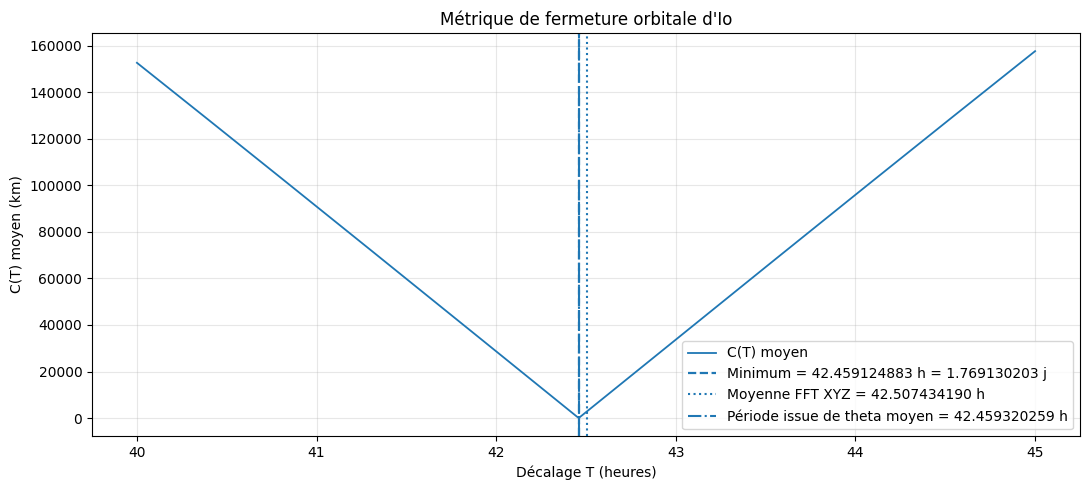

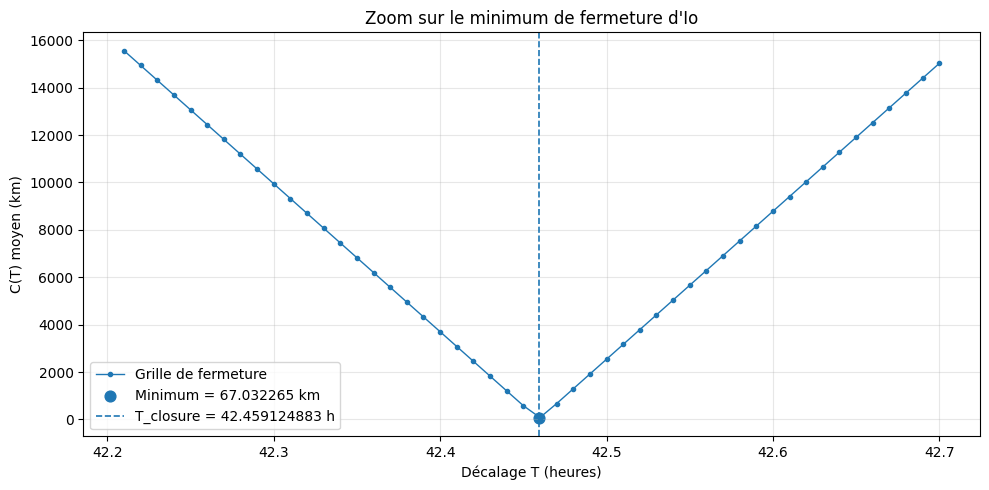

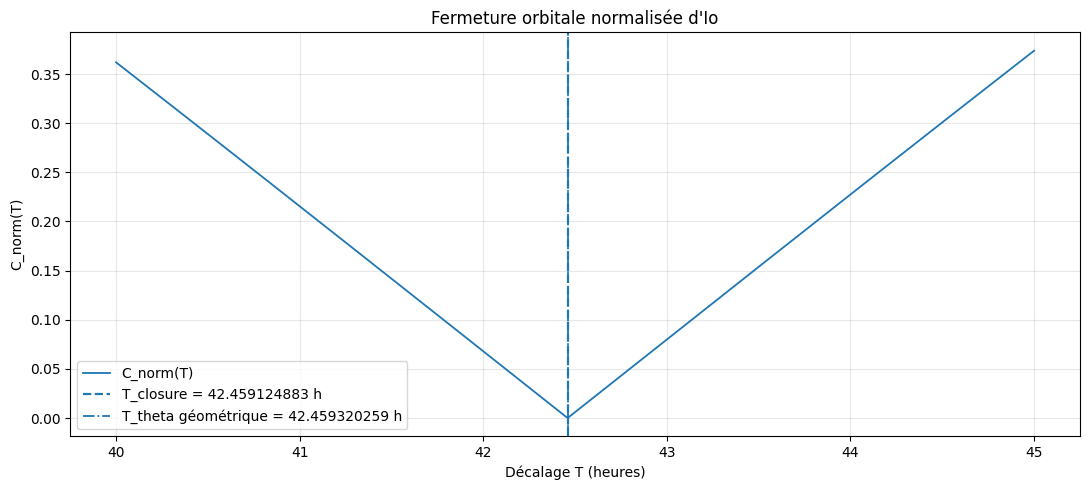

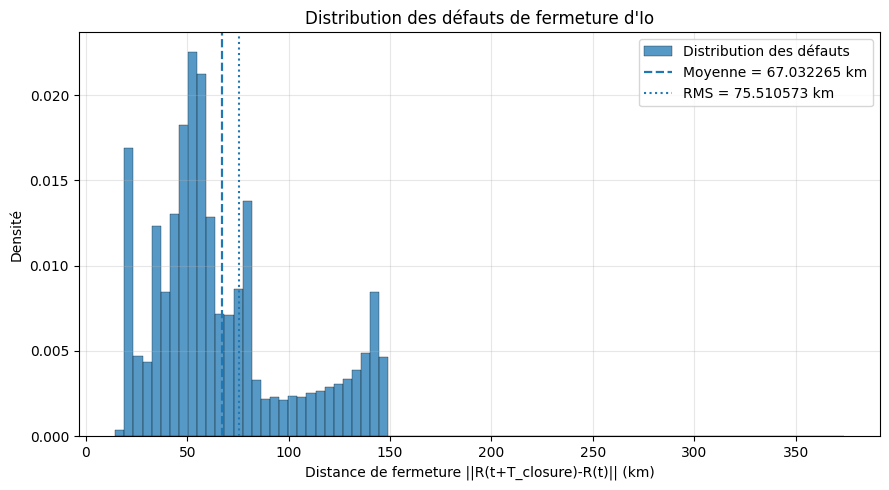

Les quatre graphiques de fermeture ont été reconstruits avec succès.


In [19]:
# ============================================================
# GRAPHIQUES CORRIGÉS — Fermeture orbitale d'Io
# Remplace entièrement les anciennes sections 10 à 13
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Ferme les figures vides éventuellement encore ouvertes
plt.close("all")


# ------------------------------------------------------------
# 10. Courbe complète de fermeture
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    fermeture_grille_io["T_heures"],
    fermeture_grille_io["C_mean_km"],
    linewidth=1.3,
    label="C(T) moyen",
)

ax.axvline(
    T_closure_heures,
    linestyle="--",
    linewidth=1.6,
    label=(
        f"Minimum = {T_closure_heures:.9f} h "
        f"= {T_closure_jours:.9f} j"
    ),
)

ax.axvline(
    T_XYZ_fft_mean,
    linestyle=":",
    linewidth=1.5,
    label=f"Moyenne FFT XYZ = {T_XYZ_fft_mean:.9f} h",
)

ax.axvline(
    T_theta_geometrique,
    linestyle="-.",
    linewidth=1.5,
    label=(
        f"Période issue de theta moyen = "
        f"{T_theta_geometrique:.9f} h"
    ),
)

ax.set_xlabel("Décalage T (heures)")
ax.set_ylabel("C(T) moyen (km)")
ax.set_title("Métrique de fermeture orbitale d'Io")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 11. Zoom autour du minimum
# ------------------------------------------------------------

masque_zoom = (
    fermeture_grille_io["T_heures"]
    >= T_closure_heures - 0.25
) & (
    fermeture_grille_io["T_heures"]
    <= T_closure_heures + 0.25
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    fermeture_grille_io.loc[
        masque_zoom,
        "T_heures"
    ],
    fermeture_grille_io.loc[
        masque_zoom,
        "C_mean_km"
    ],
    marker=".",
    linewidth=1.0,
    label="Grille de fermeture",
)

ax.scatter(
    [T_closure_heures],
    [C_best_km],
    s=60,
    label=f"Minimum = {C_best_km:.6f} km",
)

ax.axvline(
    T_closure_heures,
    linestyle="--",
    linewidth=1.2,
    label=f"T_closure = {T_closure_heures:.9f} h",
)

ax.set_xlabel("Décalage T (heures)")
ax.set_ylabel("C(T) moyen (km)")
ax.set_title("Zoom sur le minimum de fermeture d'Io")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 12. Fermeture normalisée
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    fermeture_grille_io["T_heures"],
    fermeture_grille_io["C_norm"],
    linewidth=1.3,
    label="C_norm(T)",
)

ax.axvline(
    T_closure_heures,
    linestyle="--",
    linewidth=1.6,
    label=f"T_closure = {T_closure_heures:.9f} h",
)

ax.axvline(
    T_theta_geometrique,
    linestyle="-.",
    linewidth=1.3,
    label=(
        f"T_theta géométrique = "
        f"{T_theta_geometrique:.9f} h"
    ),
)

ax.set_xlabel("Décalage T (heures)")
ax.set_ylabel("C_norm(T)")
ax.set_title("Fermeture orbitale normalisée d'Io")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 13. Distribution des défauts au meilleur T
# ------------------------------------------------------------

t_max_commun = duree_totale_heures - T_closure_heures

t_base_best = np.arange(
    0.0,
    t_max_commun + 1e-12,
    1.0,
    dtype=float,
)

R_initial_best = evaluer_position(
    t_base_best
)

R_decale_best = evaluer_position(
    t_base_best + T_closure_heures
)

distances_best_km = np.linalg.norm(
    R_decale_best - R_initial_best,
    axis=1,
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    distances_best_km,
    bins=80,
    density=True,
    edgecolor="black",
    linewidth=0.3,
    alpha=0.75,
    label="Distribution des défauts",
)

ax.axvline(
    C_best_km,
    linestyle="--",
    linewidth=1.6,
    label=f"Moyenne = {C_best_km:.6f} km",
)

ax.axvline(
    C_best_rms_km,
    linestyle=":",
    linewidth=1.5,
    label=f"RMS = {C_best_rms_km:.6f} km",
)

ax.set_xlabel(
    "Distance de fermeture ||R(t+T_closure)-R(t)|| (km)"
)
ax.set_ylabel("Densité")
ax.set_title("Distribution des défauts de fermeture d'Io")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()
plt.close(fig)

print("Les quatre graphiques de fermeture ont été reconstruits avec succès.")

## 11. Validation externe par la période orbitale de référence

Les périodes reconstruites par le pipeline sont comparées à une période
sidérale moyenne de référence pour Io :

\[
T_{\mathrm{JPL}}=1.769137786\ \mathrm{jours}.
\]

En heures :

\[
T_{\mathrm{JPL}}=42.459306864\ \mathrm{h}.
\]

Pour chaque estimation \(T_i\), on calcule l'écart signé :

\[
\Delta T_i=T_i-T_{\mathrm{JPL}},
\]

l'erreur absolue en secondes :

\[
E_{\mathrm{abs},i}
=
|\Delta T_i|\times3600,
\]

l'erreur relative :

\[
E_{\mathrm{rel},i}
=
\frac{|\Delta T_i|}{T_{\mathrm{JPL}}},
\]

ainsi que son expression en pourcentage et en parties par million :

\[
E_{\%,i}=100E_{\mathrm{rel},i},
\]

\[
E_{\mathrm{ppm},i}=10^6E_{\mathrm{rel},i}.
\]

Cette comparaison confronte la période de référence aux estimations obtenues
par fermeture orbitale, géométrie angulaire et analyse fréquentielle.

VALIDATION EXTERNE DE LA PÉRIODE ORBITALE — Io
Période sidérale moyenne de référence adoptée : 1.769137786000 jours
Période sidérale moyenne de référence adoptée : 42.459306864000 heures
Période sidérale moyenne de référence adoptée : 152853.504710 secondes

TABLEAU PRINCIPAL


,Méthode,Période (jours),Période (heures),Écart signé (s),Erreur absolue (s),Erreur relative (%),Erreur relative (ppm)
0,Reference_siderale_adoptee,1.769137786000,42.459306864000,+0.000000,0.000000,0.000000000,0.000000
1,Fermeture_orbitale,1.769130203473,42.459124883359,-0.655130,0.655130,0.000428600,4.286001
2,Theta_geometrique,1.769138344135,42.459320259251,+0.048223,0.048223,0.000031548,0.315484
3,FFT_XYZ_moyenne,1.771143091251,42.507434190021,+173.258374,173.258374,0.113349297,1133.492974



CLASSEMENT PAR PROXIMITÉ AVEC LA RÉFÉRENCE


,Rang,Methode,T_heures,Erreur_absolue_secondes,Erreur_relative_pct,Erreur_relative_ppm
0,1,Theta_geometrique,42.459320259251,0.048223,0.000031548,0.315484
1,2,Fermeture_orbitale,42.459124883359,0.655130,0.000428600,4.286001
2,3,FFT_XYZ_moyenne,42.507434190021,173.258374,0.113349297,1133.492974



COMPARAISONS INTERNES ENTRE LES MÉTHODES


,Comparaison,Ecart_absolu_heures,Ecart_absolu_secondes
0,Fermeture - theta géométrique,0.000195375892,0.703353
1,Fermeture - FFT XYZ,0.048309306662,173.913504
2,Theta géométrique - FFT XYZ,0.048113930770,173.210151


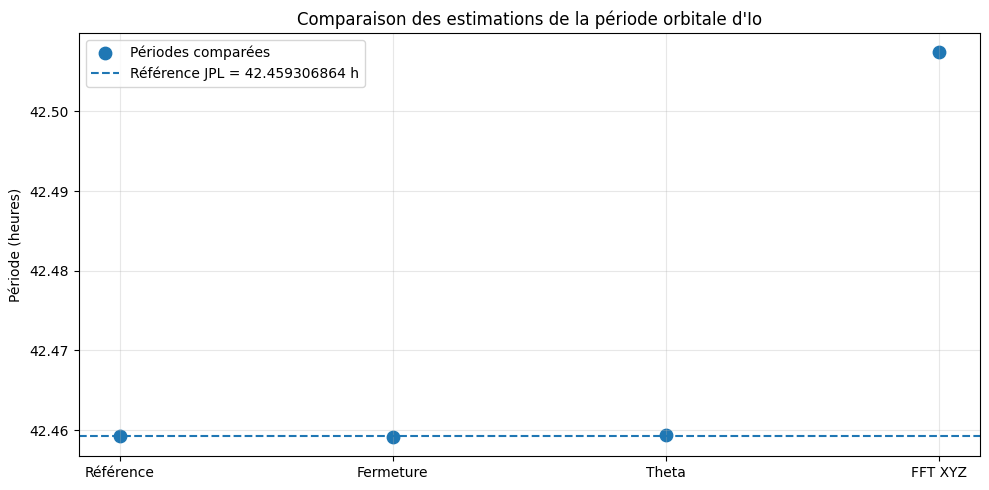

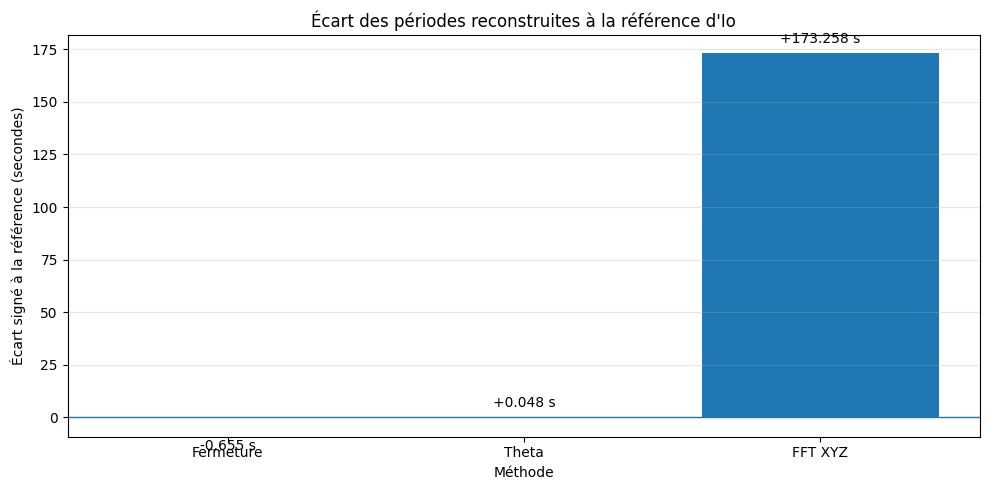


CONTRÔLES DE VALIDATION EXTERNE


,Controle,Valeur,Validation_globale
0,Référence JPL finie et positive,True,True
1,Toutes les périodes sont finies et positives,True,True
2,Toutes les erreurs sont finies,True,True
3,Erreur theta géométrique inférieure à 1 s,True,True
4,Erreur de fermeture inférieure à 1 s,True,True



RÉSUMÉ FINAL — VALIDATION EXTERNE D'Io
T_JPL                     : 42.459306864000 h
T_closure                 : 42.459124883359 h
Erreur absolue fermeture  : 0.655130 s
Erreur fermeture          : 4.286001 ppm
T_theta                   : 42.459320259251 h
Erreur absolue theta      : 0.048223 s
Erreur theta              : 0.315484 ppm
T_FFT_XYZ                 : 42.507434190021 h
Erreur absolue FFT XYZ    : 173.258374 s
Erreur FFT XYZ            : 1133.492974 ppm
Écart fermeture–theta     : 0.703353 s

Validation externe globale réussie.


In [22]:
# ============================================================
# Étape 11 — Validation externe de la période orbitale d'Io
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Vérification des résultats nécessaires
# ------------------------------------------------------------

variables_requises = [
    "T_closure_heures",
    "T_theta_geometrique",
    "T_XYZ_fft_mean",
]

variables_absentes = [
    nom
    for nom in variables_requises
    if nom not in globals()
]

if variables_absentes:
    raise NameError(
        "Variables absentes : "
        + ", ".join(variables_absentes)
        + ". Exécuter d'abord les analyses FFT et de fermeture."
    )


# ------------------------------------------------------------
# 2. Période orbitale moyenne de référence
# ------------------------------------------------------------

# Période sidérale moyenne de référence d'Io.
# La valeur est définie explicitement afin d'assurer la
# reproductibilité du notebook.
T_JPL_jours = 1.769137786

T_JPL_heures = float(
    T_JPL_jours * 24.0
)

T_JPL_secondes = float(
    T_JPL_heures * 3600.0
)

if not np.isfinite(T_JPL_heures) or T_JPL_heures <= 0:
    raise ValueError(
        "La période de référence doit être finie et positive."
    )


# ------------------------------------------------------------
# 3. Périodes reconstruites par le pipeline
# ------------------------------------------------------------

periodes_validation = {
    "Reference_siderale_adoptee": T_JPL_heures,
    "Fermeture_orbitale": float(T_closure_heures),
    "Theta_geometrique": float(T_theta_geometrique),
    "FFT_XYZ_moyenne": float(T_XYZ_fft_mean),
}

for nom_methode, periode in periodes_validation.items():

    if not np.isfinite(periode) or periode <= 0:
        raise ValueError(
            f"La période associée à {nom_methode} "
            "n'est pas finie ou positive."
        )


# ------------------------------------------------------------
# 4. Construction du tableau de validation
# ------------------------------------------------------------

lignes_validation = []

for methode, T_heures in periodes_validation.items():

    T_heures = float(T_heures)
    T_jours = T_heures / 24.0
    T_secondes = T_heures * 3600.0

    ecart_signe_heures = (
        T_heures - T_JPL_heures
    )

    ecart_signe_secondes = (
        ecart_signe_heures * 3600.0
    )

    erreur_absolue_heures = abs(
        ecart_signe_heures
    )

    erreur_absolue_secondes = abs(
        ecart_signe_secondes
    )

    erreur_relative = (
        erreur_absolue_heures
        / T_JPL_heures
    )

    erreur_relative_pct = (
        100.0 * erreur_relative
    )

    erreur_relative_ppm = (
        1.0e6 * erreur_relative
    )

    lignes_validation.append({
        "Methode": methode,
        "T_jours": T_jours,
        "T_heures": T_heures,
        "T_secondes": T_secondes,
        "Ecart_signe_heures": ecart_signe_heures,
        "Ecart_signe_secondes": ecart_signe_secondes,
        "Erreur_absolue_heures": erreur_absolue_heures,
        "Erreur_absolue_secondes": erreur_absolue_secondes,
        "Erreur_relative": erreur_relative,
        "Erreur_relative_pct": erreur_relative_pct,
        "Erreur_relative_ppm": erreur_relative_ppm,
    })

validation_periode_io = pd.DataFrame(
    lignes_validation
)


# ------------------------------------------------------------
# 5. Classement hors ligne de référence
# ------------------------------------------------------------

classement_periodes_io = (

    validation_periode_io.loc[

        validation_periode_io["Methode"]

        != "Reference_siderale_adoptee"

    ]

    .sort_values(

        "Erreur_absolue_secondes",

        ascending=True,

    )

    .reset_index(drop=True)

)

classement_periodes_io.insert(
    0,
    "Rang",
    np.arange(
        1,
        len(classement_periodes_io) + 1,
    )
)


# ------------------------------------------------------------
# 6. Comparaisons détaillées
# ------------------------------------------------------------

T_closure = float(T_closure_heures)
T_theta = float(T_theta_geometrique)
T_fft_xyz = float(T_XYZ_fft_mean)

ecart_closure_theta_secondes = (
    abs(T_closure - T_theta) * 3600.0
)

ecart_closure_fft_secondes = (
    abs(T_closure - T_fft_xyz) * 3600.0
)

ecart_theta_fft_secondes = (
    abs(T_theta - T_fft_xyz) * 3600.0
)

comparaisons_internes_io = pd.DataFrame({
    "Comparaison": [
        "Fermeture - theta géométrique",
        "Fermeture - FFT XYZ",
        "Theta géométrique - FFT XYZ",
    ],
    "Ecart_absolu_heures": [
        abs(T_closure - T_theta),
        abs(T_closure - T_fft_xyz),
        abs(T_theta - T_fft_xyz),
    ],
    "Ecart_absolu_secondes": [
        ecart_closure_theta_secondes,
        ecart_closure_fft_secondes,
        ecart_theta_fft_secondes,
    ],
})


# ------------------------------------------------------------
# 7. Tableau résumé compact
# ------------------------------------------------------------

tableau_validation_compact_io = (
    validation_periode_io[
        [
            "Methode",
            "T_jours",
            "T_heures",
            "Ecart_signe_secondes",
            "Erreur_absolue_secondes",
            "Erreur_relative_pct",
            "Erreur_relative_ppm",
        ]
    ]
    .copy()
)

tableau_validation_compact_io = (
    tableau_validation_compact_io
    .rename(columns={
        "Methode": "Méthode",
        "T_jours": "Période (jours)",
        "T_heures": "Période (heures)",
        "Ecart_signe_secondes": "Écart signé (s)",
        "Erreur_absolue_secondes": "Erreur absolue (s)",
        "Erreur_relative_pct": "Erreur relative (%)",
        "Erreur_relative_ppm": "Erreur relative (ppm)",
    })
)


# ------------------------------------------------------------
# 8. Affichage des tableaux
# ------------------------------------------------------------

print("=" * 95)
print("VALIDATION EXTERNE DE LA PÉRIODE ORBITALE — Io")
print("=" * 95)

print(
    f"Période sidérale moyenne de référence adoptée : "
    f"{T_JPL_jours:.12f} jours"
)

print(
    f"Période sidérale moyenne de référence adoptée : "
    f"{T_JPL_heures:.12f} heures"
)

print(
    f"Période sidérale moyenne de référence adoptée : "
    f"{T_JPL_secondes:.6f} secondes"
)

print("\nTABLEAU PRINCIPAL")

display(
    tableau_validation_compact_io.style.format({
        "Période (jours)": "{:.12f}",
        "Période (heures)": "{:.12f}",
        "Écart signé (s)": "{:+.6f}",
        "Erreur absolue (s)": "{:.6f}",
        "Erreur relative (%)": "{:.9f}",
        "Erreur relative (ppm)": "{:.6f}",
    })
)

print("\nCLASSEMENT PAR PROXIMITÉ AVEC LA RÉFÉRENCE")

display(
    classement_periodes_io[
        [
            "Rang",
            "Methode",
            "T_heures",
            "Erreur_absolue_secondes",
            "Erreur_relative_pct",
            "Erreur_relative_ppm",
        ]
    ].style.format({
        "T_heures": "{:.12f}",
        "Erreur_absolue_secondes": "{:.6f}",
        "Erreur_relative_pct": "{:.9f}",
        "Erreur_relative_ppm": "{:.6f}",
    })
)

print("\nCOMPARAISONS INTERNES ENTRE LES MÉTHODES")

display(
    comparaisons_internes_io.style.format({
        "Ecart_absolu_heures": "{:.12f}",
        "Ecart_absolu_secondes": "{:.6f}",
    })
)


# ------------------------------------------------------------
# 9. Graphique des périodes
# ------------------------------------------------------------

methodes_graphique = [
    "Référence",
    "Fermeture",
    "Theta",
    "FFT XYZ",
]

periodes_graphique = np.array([
    T_JPL_heures,
    T_closure,
    T_theta,
    T_fft_xyz,
])

ecarts_secondes_graphique = (
    (periodes_graphique - T_JPL_heures)
    * 3600.0
)

fig, ax = plt.subplots(figsize=(10, 5))

positions = np.arange(
    len(methodes_graphique)
)

ax.scatter(
    positions,
    periodes_graphique,
    s=80,
    label="Périodes comparées",
)

ax.axhline(
    T_JPL_heures,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Référence JPL = "
        f"{T_JPL_heures:.9f} h"
    ),
)

ax.set_xticks(
    positions
)

ax.set_xticklabels(
    methodes_graphique
)

ax.set_ylabel("Période (heures)")
ax.set_title(
    "Comparaison des estimations de la période orbitale d'Io"
)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 10. Graphique des écarts signés en secondes
# ------------------------------------------------------------

methodes_erreurs = [
    "Fermeture",
    "Theta",
    "FFT XYZ",
]

erreurs_signees_secondes = np.array([
    (T_closure - T_JPL_heures) * 3600.0,
    (T_theta - T_JPL_heures) * 3600.0,
    (T_fft_xyz - T_JPL_heures) * 3600.0,
])

fig, ax = plt.subplots(figsize=(10, 5))

barres = ax.bar(
    methodes_erreurs,
    erreurs_signees_secondes,
    label="Écart signé à la référence",
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel("Méthode")
ax.set_ylabel("Écart signé à la référence (secondes)")
ax.set_title(
    "Écart des périodes reconstruites à la référence d'Io"
)
ax.grid(
    axis="y",
    alpha=0.3,
)

for barre, valeur in zip(
    barres,
    erreurs_signees_secondes,
):
    ax.annotate(
        f"{valeur:+.3f} s",
        xy=(
            barre.get_x()
            + barre.get_width() / 2.0,
            valeur,
        ),
        xytext=(
            0,
            5 if valeur >= 0 else -15,
        ),
        textcoords="offset points",
        ha="center",
        va=(
            "bottom"
            if valeur >= 0
            else "top"
        ),
    )

fig.tight_layout()
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 11. Validation automatique
# ------------------------------------------------------------

validation_reference = bool(
    np.isfinite(T_JPL_heures)
    and T_JPL_heures > 0
)

validation_periodes = bool(
    np.isfinite(
        periodes_graphique
    ).all()
    and (
        periodes_graphique > 0
    ).all()
)

validation_erreurs = bool(
    np.isfinite(
        validation_periode_io[
            "Erreur_absolue_secondes"
        ]
    ).all()
)

validation_theta_sous_1s = bool(
    abs(
        T_theta - T_JPL_heures
    ) * 3600.0 < 1.0
)

validation_closure_sous_1s = bool(
    abs(
        T_closure - T_JPL_heures
    ) * 3600.0 < 1.0
)

controle_validation_externe_io = pd.DataFrame({
    "Controle": [
        "Référence JPL finie et positive",
        "Toutes les périodes sont finies et positives",
        "Toutes les erreurs sont finies",
        "Erreur theta géométrique inférieure à 1 s",
        "Erreur de fermeture inférieure à 1 s",
    ],
    "Valeur": [
        validation_reference,
        validation_periodes,
        validation_erreurs,
        validation_theta_sous_1s,
        validation_closure_sous_1s,
    ],
})

controle_validation_externe_io[
    "Validation_globale"
] = (
    controle_validation_externe_io[
        "Valeur"
    ].astype(bool)
)

validation_externe_globale_io = bool(
    controle_validation_externe_io[
        "Validation_globale"
    ].all()
)

print("\n" + "=" * 95)
print("CONTRÔLES DE VALIDATION EXTERNE")
print("=" * 95)

display(
    controle_validation_externe_io
)


# ------------------------------------------------------------
# 12. Résumé numérique final
# ------------------------------------------------------------

ligne_closure = validation_periode_io.loc[
    validation_periode_io["Methode"]
    == "Fermeture_orbitale"
].iloc[0]

ligne_theta = validation_periode_io.loc[
    validation_periode_io["Methode"]
    == "Theta_geometrique"
].iloc[0]

ligne_fft = validation_periode_io.loc[
    validation_periode_io["Methode"]
    == "FFT_XYZ_moyenne"
].iloc[0]

print("\n" + "=" * 95)
print("RÉSUMÉ FINAL — VALIDATION EXTERNE D'Io")
print("=" * 95)

print(
    f"T_JPL                     : "
    f"{T_JPL_heures:.12f} h"
)

print(
    f"T_closure                 : "
    f"{T_closure:.12f} h"
)

print(
    f"Erreur absolue fermeture  : "
    f"{ligne_closure['Erreur_absolue_secondes']:.6f} s"
)

print(
    f"Erreur fermeture          : "
    f"{ligne_closure['Erreur_relative_ppm']:.6f} ppm"
)

print(
    f"T_theta                   : "
    f"{T_theta:.12f} h"
)

print(
    f"Erreur absolue theta      : "
    f"{ligne_theta['Erreur_absolue_secondes']:.6f} s"
)

print(
    f"Erreur theta              : "
    f"{ligne_theta['Erreur_relative_ppm']:.6f} ppm"
)

print(
    f"T_FFT_XYZ                 : "
    f"{T_fft_xyz:.12f} h"
)

print(
    f"Erreur absolue FFT XYZ    : "
    f"{ligne_fft['Erreur_absolue_secondes']:.6f} s"
)

print(
    f"Erreur FFT XYZ            : "
    f"{ligne_fft['Erreur_relative_ppm']:.6f} ppm"
)

print(
    f"Écart fermeture–theta     : "
    f"{ecart_closure_theta_secondes:.6f} s"
)

if validation_externe_globale_io:
    print(
        "\nValidation externe globale réussie."
    )
else:
    print(
        "\nAttention : au moins un contrôle "
        "de validation externe a échoué."
    )

### Conclusion de la validation externe

La période géométrique dérivée de l’angle moyen fournit l’estimation la
plus proche de la période sidérale moyenne de référence adoptée :

\[
T_\theta = 42.459320259\ \mathrm{h},
\]

avec une erreur absolue de seulement :

\[
0.048223\ \mathrm{s}
\]

et une erreur relative de :

\[
0.315484\ \mathrm{ppm}.
\]

La période obtenue par fermeture orbitale atteint également une précision
subseconde :

\[
T_{\mathrm{closure}} = 42.459124883\ \mathrm{h},
\]

avec une erreur absolue de :

\[
0.655130\ \mathrm{s}.
\]

Les deux reconstructions géométriques ne diffèrent entre elles que de :

\[
0.703353\ \mathrm{s}.
\]

La moyenne des périodes FFT des coordonnées \(X,Y,Z\) reste correctement
située dans la famille orbitale, mais présente une erreur plus importante
de \(173.258374\ \mathrm{s}\), compatible avec la résolution fréquentielle
finie, la fuite spectrale et l’interpolation du pic.

Ces résultats montrent que, pour les éphémérides jovicentriques d’Io
étudiées ici, les observables géométriques locales et la fermeture globale
reconstruisent la période orbitale avec une précision nettement supérieure
à celle du pic FFT direct.